Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Часть 1 (6+ pt)

В этом домашнем задании вы познакомитесь с **разведовательным анализом** (EDA). На самом деле, разведывательный анализ — это не что-то съверхестественное. Более того, в предыдущих заданиях вы уже в какой-то мере его совершали.

**EDA (Exploratory Data Analysis)** — это первый и критически важный этап работы с данными, на котором вы «знакомитесь» с набором данных через визуализации и статистические резюме. Через EDA:
> - Обнаруживаете аномалии и пропуски
> - Понимаете распределение признаков
> - Выявляете взаимосвязи между переменными
> - Формулируете гипотезы для дальнейшей проверки

Звучит знакомо, правда?

Поэтому в этой домашке мы скорее соберем все навыки воедино и дополним их **статистикой** и **визуализацией**!

Будем руководствоваться следующими вопросами:
* Как распределены значения признаков?
* Какие признаки связаны между собой?
* Какие закономерности скрыты в данных?
* Какие гипотезы можно сформулировать для дальнейшего анализа?

В ноутбуке как всегда будут теоретические справки, но полезно еще почитать [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Understanding Correlation](https://seaborn.pydata.org/examples/many_pairwise_correlations.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Pandas Statistical Functions](https://pandas.pydata.org/docs/reference/general_functions.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7#computational-descriptive-stats).

***
В этой части будем использовать датасет `diamonds` из `seaborn` (значения столбцов можно посмотреть в интернетах). Мы уже умеем загружать такие датасеты, сделаем это.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 3.0.0
Seaborn version: 0.13.2


In [2]:
diamonds = sns.load_dataset('diamonds')
diamonds.shape

(53940, 10)

### Знакомство с данными (1 pt)

**ЗАДАНИЕ: базово исследуйте и очистите данные, напишите небольшой вывод.**

Можете ориентироваться на следующие важные пункты:
* Столбцы, их значение и типы их значений
* Количество уникальных значений
* Границы значений
* Пропуски
* Дубликаты

In [3]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
diamonds.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Окей, пропусков нигде нет. Посмотрим дубликаты

In [5]:
diamonds.duplicated().sum()

146

In [6]:
diamonds = diamonds.drop_duplicates()
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Мне показалось очень странным, что если x,y,z это размеры, то есть алмазы с размером 0 по какой-то из осей?? 
Из "физики дела" следует, что это аномалия, которую стоит убрать. Мне также кажется странным, что есть алмазы, размер которых по какой-то из осей превышает 20, я бы тоже это счёл за аномалию и убрал. Попробуем сделать умнее: если приблизительный объём не соотносится с весом, будем предполагать, что это аномалия и убирать. Сделаем это далее:

In [7]:
diamonds = diamonds[(diamonds.x != 0) & (diamonds.y != 0) & (diamonds.z != 0)]

Если средняя цена всех алмазов 4000, а у алмазов с такими размерами она 12400, наверное, это не ошибка. table и depth тоже соотносятся с предполагаемыми размерами. Думаю, не стоит убирать большие алмазы: физике дела не противоречат, просто могут сильно повлиять на данные. В дальнейшем посмотрим, насколько велико их влияние при анализе. 

Кстати о table и depth: если я правильно понимаю, у неё есть конкретная формула, которой они должны соответствовать. Тут я нашёл информацию о том, какую table и depth в идеале (в процентах) должна иметь та или иная форма алмаза:
https://www.withclarity.com/blogs/diamond/what-is-diamond-depth

Почитал про GIA, потому что понял, что в этом датасете используется именно эта классификация (https://dzen.ru/a/YuAc8qjpd18hIAFw)

> Качество огранки (Cut Grade) — характеристика, которая указывается только для бриллиантов круглой формы. Именно от нее зависит, насколько хорошо камень будет отражать свет. 
> GIA выделяет 5 уровней качества огранки:
> - excellent — отличная,
> - very Good — очень хорошая,
> - good — хорошая,
> - fair — посредственная,
> - poor — плохая.

Отсюда делаем вывод, что все наши камни круглые! Попробуем понять, есть ли аномалии. Проблема в том, что в разных источниках для круглых алмазов указывают совсем разные идеальные диапазоны round и depth. Буду использовать из таблицы по первой ссылке.

In [8]:
diamonds['depth_ideal'] = diamonds['depth'].between(59, 62.3)
diamonds['table_ideal'] = diamonds['table'].between(53.0, 58.0)
diamonds['overall_ideal'] = diamonds['depth_ideal'] & diamonds['table_ideal']
print("Доля алмазов, попадающих в идеальные диапазоны\n")
cut_stats = diamonds.groupby('cut')[['depth_ideal', 'table_ideal', 'overall_ideal']].mean()
print(cut_stats)

extreme = diamonds[(diamonds.depth < 50) | (diamonds.depth > 70) | (diamonds.table < 40) | (diamonds.table > 80)]
print(f"\nАлмазы с экстремальными depth/table (возможные ошибки): {len(extreme)}")
print(extreme[['carat', 'cut', 'depth', 'table', 'price']].head(10))

Доля алмазов, попадающих в идеальные диапазоны

           depth_ideal  table_ideal  overall_ideal
cut                                               
Ideal         0.828625     0.974028       0.805259
Premium       0.757662     0.444129       0.325180
Very Good     0.522705     0.626367       0.286460
Good          0.181465     0.521686       0.022913
Fair          0.078272     0.529743       0.008140

Алмазы с экстремальными depth/table (возможные ошибки): 26
       carat    cut  depth  table  price
4307    0.99   Fair   71.6   57.0   3593
4518    1.00   Fair   43.0   59.0   3634
6341    1.00   Fair   44.0   53.0   4032
8014    1.50   Fair   70.1   58.0   4328
8186    1.50   Fair   71.3   58.0   4368
8356    1.02   Fair   70.6   57.0   4398
8672    1.02   Fair   71.8   56.0   4455
10377   1.09  Ideal   43.0   54.0   4778
15781   2.01   Fair   70.2   57.0   6315
16439   2.22   Fair   70.1   55.0   6564


Ну, мы видим прямую связь между качеством огранки и соответствию алмаза идеальному размеру. Кажется, так и должно быть, ведь cut как раз и присуждается исходя из table и depth, как я понимаю.

Следующая идея - проверить carat, потому что есть значение 5, что довольно много. Размеры таких алмазов должны соотноситься с их весом. Как я выяснил, для круглых бриллиантов стандартной огранки GIA и другие лаборатории используют следующую формулу для приблизительного расчёта веса в каратах:

Караты = средний диаметр^2 * глубина * 0.0061 (эмпирический коэфф.) 

В нашем случае диаметр = (x+y)/2, глубина равна z.

Проверим!

In [9]:
diamonds['carat_est'] = ((diamonds['x'] + diamonds['y']) / 2) ** 2 * diamonds['z'] * 0.0061

# Относительная ошибка (можно использовать абсолютную разницу, но относительная кажется более выразительной)
diamonds['carat_diff'] = abs(diamonds['carat'] - diamonds['carat_est']) / diamonds['carat_est']

# Посмотрим на тяжёлые алмазы
diamonds_sorted = diamonds.sort_values('carat_diff', ascending=False)
print("Тяжёлые алмазы с наибольшей относительной ошибкой оценки веса:")
print(diamonds_sorted[['carat', 'x', 'y', 'z', 'carat_est', 'carat_diff', 'depth', 'table', 'price']].head(20))

Тяжёлые алмазы с наибольшей относительной ошибкой оценки веса:
       carat     x      y      z  carat_est  carat_diff  depth  table  price
14635   1.07  6.62   6.67   1.07   0.288206    2.712617   60.6   57.0   5909
21654   1.41  7.31   7.22   1.41   0.453963    2.105982   60.7   56.0   9752
20694   1.53  7.43   7.50   1.53   0.520093    1.941782   61.9   54.0   8971
24067   2.00  8.09  58.90   8.06  55.160074    0.963742   58.9   57.0  12210
49189   0.51  5.15  31.80   5.12  10.660282    0.952159   61.8   55.0   2075
48410   0.51  5.12   5.15  31.80   5.114908    0.900291   61.8   54.7   1970
25849   2.00  6.16   6.15   4.82   1.113866    0.795548   59.0   62.0  14918
17826   1.51  7.08   4.70   4.00   0.846487    0.783843   65.6   56.0   7188
2274    1.22  6.79   4.24   3.76   0.697604    0.748844   62.6   59.0   3156
26495   2.06  6.29   6.25   4.96   1.189451    0.731891   60.0   60.0  16098
15235   1.12  6.64   4.11   3.70   0.652061    0.717630   61.6   58.0   6115
41020   0.25 

In [10]:
# Удаляем записи с ошибкой > 0.5 (50%)
diamonds = diamonds[diamonds['carat_diff'] <= 0.5].copy()

# Дополнительно можно проверить соотношение x и y
diamonds['xy_ratio'] = diamonds[['x', 'y']].max(axis=1) / diamonds[['x', 'y']].min(axis=1)
# Оставляем только те, где отношение меньше 1.2 (т.е. x и y примерно равны)
diamonds = diamonds[diamonds['xy_ratio'] <= 1.2].copy()

# Смотрим, сколько удалилось
print(f"Осталось записей после очистки: {len(diamonds)}")

Осталось записей после очистки: 53757


Почистили все значения с большой ошибкой или нереалистичным соотношением размеров (исходя из того, что алмазы у нас круглые). Родилась ещё одна идея предобработки: хочется проверить не оптимальные, а **допустимые** значения depth и table:

Про depth:
- Круглый бриллиант классической огранки (57 или 58 граней) имеет строго определённую оптическую схему
- Глубина круглого алмаза складывается из высоты короны (верхней части) и павильона (нижней части)
- Угол павильона обычно составляет 40–42 градусов, угол короны - 30–35 градусов
- Тогда высота павильона примерно 45% от диаметра, а высота короны - около 15%

Получаем, что если depth < 50%, это означает, что павильон слишком плоский (угол < 38) или корона почти отсутствует. Геометрически при depth < 50% просто не хватит места для размещения 16 нижних граней павильона (у круглого алмаза их 16 или 32) с сохранением их симметрии.

Про table: 
- Самая большая верхняя грань, для круглых алмазов восьмиугольная
- Если table > 80%, то грань слишком низкая, свет почти не преломляется и камень становится похожим на стекло
Геометрически при table > 80% невозможно разместить 16 верхних граней короны (у круглого алмаза их обычно 16 или 32).


In [11]:
# Удаление физически невозможных depth и table
diamonds = diamonds[(diamonds['depth'] >= 50) & (diamonds['depth'] <= 70) &
                    (diamonds['table'] >= 40) & (diamonds['table'] <= 80)].copy()

print(f"Осталось записей после очистки: {len(diamonds)}")

Осталось записей после очистки: 53731


In [12]:
print(diamonds['cut'].value_counts())
print()
print(diamonds['color'].value_counts())
print()
print(diamonds['clarity'].value_counts())

cut
Ideal        21479
Premium      13728
Very Good    12067
Good          4887
Fair          1570
Name: count, dtype: int64

color
G    11244
E     9770
F     9510
H     8254
D     6752
I     5402
J     2799
Name: count, dtype: int64

clarity
SI1     13021
VS2     12219
SI2      9130
VS1      8149
VVS2     5055
VVS1     3646
IF       1784
I1        727
Name: count, dtype: int64


Ну, тоже всё ок. Напоследок ещё проверим все типы

In [13]:
diamonds.dtypes

carat             float64
cut              category
color            category
clarity          category
depth             float64
table             float64
price               int64
x                 float64
y                 float64
z                 float64
depth_ideal          bool
table_ideal          bool
overall_ideal        bool
carat_est         float64
carat_diff        float64
xy_ratio          float64
dtype: object

In [14]:
diamonds.describe()

,carat,depth,table,price,x,y,z,carat_est,carat_diff,xy_ratio
count,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000,53731.000000
mean,0.797255,61.745369,57.457069,3930.241983,5.731100,5.733239,3.538996,0.791536,0.014970,1.008056
std,0.472970,1.407468,2.225943,3985.201088,1.118607,1.110551,0.690690,0.465789,0.014334,0.004216
min,0.200000,50.800000,43.000000,326.000000,3.730000,3.680000,2.060000,0.193428,0.000001,1.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000,0.397754,0.005471,1.005472
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,0.700588,0.011624,1.007143
75%,1.040000,62.500000,59.000000,5322.500000,6.540000,6.540000,4.030000,1.042032,0.020278,1.009569
max,5.010000,70.000000,79.000000,18823.000000,10.740000,10.540000,6.980000,4.820238,0.491726,1.168717


Всё в порядке, проблем не вижу. Напишем вывод!

### Вывод
1) Датасет содержит 53940 записей о характеристиках алмазов. Были обнаружены и удалены 146 дубликатов
2) Пропусков в данных не обнаружено
3) Все столбцы соответствуют ожидаемым типам данных. Уникальные значения по категориям:
    - cut: Fair, Good, Very Good, Premium, Ideal, 
    - color: D, E, F, G, H, I, J,
    - clarity: I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF
5) Нашли алмазы с нулевыми значениями размеров (аномалии). Эти алмазы были удалены
6) Относительная ошибка между фактическим и расчётным весом у большинства записей не превышает 20%. Записи с ошибкой более 50% были удалены, они говорят либо об опечатках в размерах/весе, либо о том, что камень имеет не круглую форму. Также были исключены записи, где оси x и y сильно различаются (отношение max/min > 1.2) – это дополнительный признак некруглой огранки
7) Удаление физически невозможных значений depth и table
    На основе геометрических и оптических ограничений для круглых алмазов были определены допустимые границы:
    - depth должен находиться в интервале [50, 70] (иначе камень либо слишком плоский, либо слишком глубокий, что не позволяет граням правильно отражать свет).
    - table должен быть в пределах [40, 80] (при большей таблице корона практически исчезает, камень теряет блеск)

### Одномерный анализ (3 pt)

После того, как вы «окинули взглядом» данные и применили те методы, которые уже знаете, перейдем к статистическому анализу и более глубокому пониманию.

В этом пункте мы поговорим про **одномерный анализ**, то есть про анализ каждого признака по отдельности _(можно найти и другие определения, не претендую на единсвенно верное)_.

Важными для одномерного анализа являются **мера центральности** и **мера разброса**, а также сама форма распределений. Давайте поговорим про них по отдельности.

***
Центрирование данных можно описать через три ключевые меры:
| Мера | Функция | Когда использовать |
| ---- | ------- | ------------------ |
| **Среднее** | `.mean()` | Для симметричных распределений без выбросов |
| **Медиана** | `.median()` | Для асимметричных распределений или при наличии выбросов |
| **Мода** (наиболее частое значение) | `.mode()` | Для категориальных данных или мультимодальных распределений |

Все три меры, безусловно, дают нам информацию о распределении данных и мы можем делать из этого выводы (например если среднее сильно отличается от медианы). Однако пукнт _«Когда использовать»_ говорит о том, когда эту меру стоит использовать для информативного описания распределения в дальнейшем (или для использования статистики при каких-то вычислениях).

Сначала хочется обосновать, что почему и как:
- для cut, color и clarity используем медиану, потому что данные категориальные
- для carat, depth, table, price, x,y,z сначала построим гистограмму, чтобы понять, есть ли выбросы, потом выберем, среднее или медиану

Мода для cut: Ideal
Мода для color: G
Мода для clarity: SI1


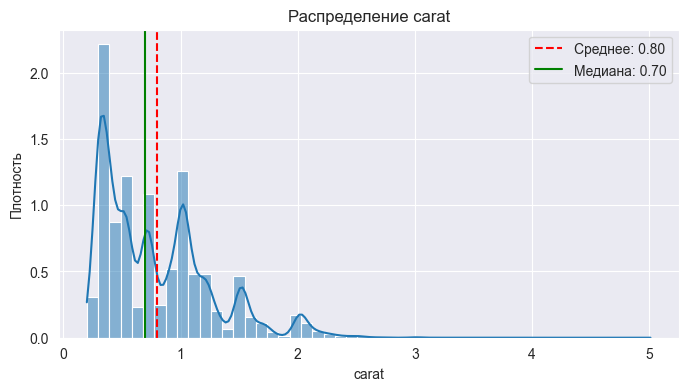

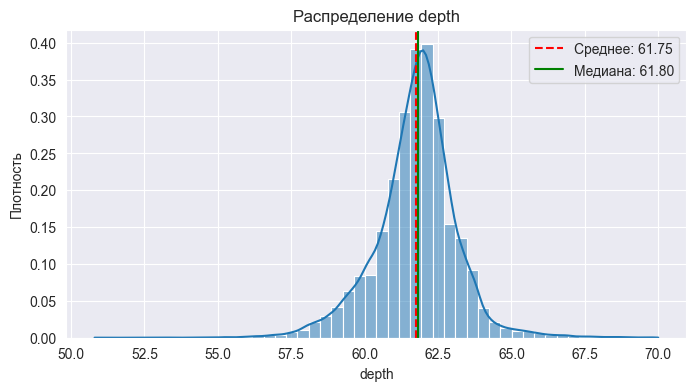

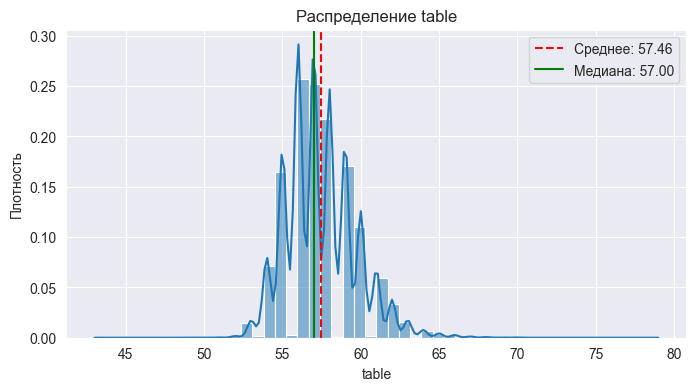

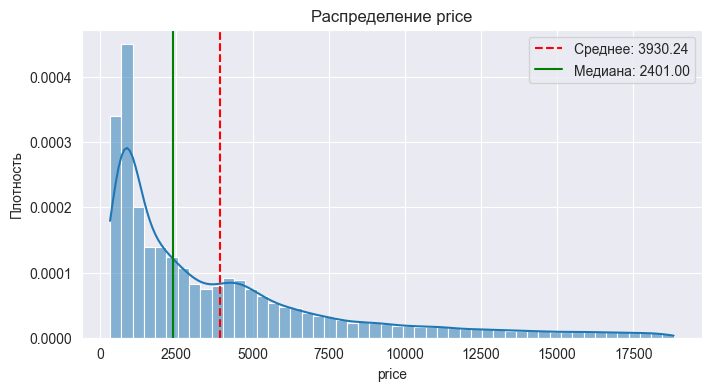

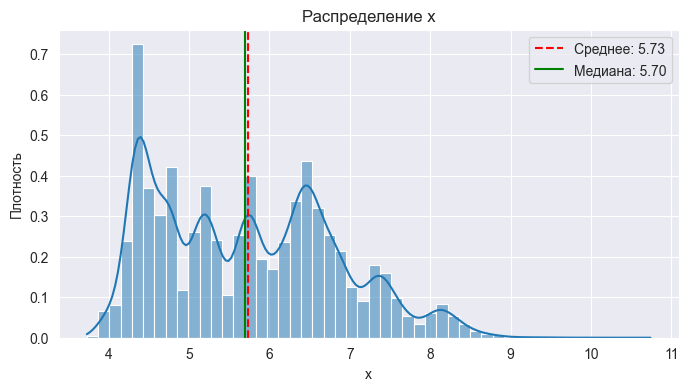

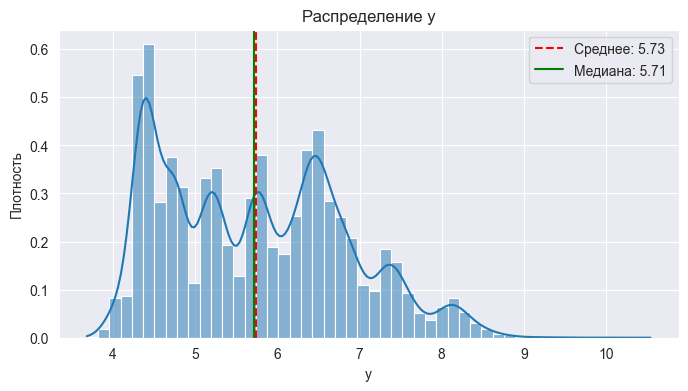

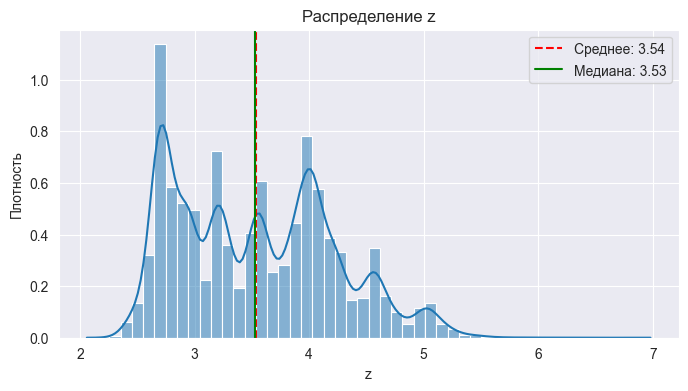

In [15]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Объясните расхождения между средним и медианой, если такие есть.
#          3. Напишите вывод (ваши гипотезы) о распределении данных на основе мер центральности
print("Мода для cut:", diamonds['cut'].mode()[0])
print("Мода для color:", diamonds['color'].mode()[0])
print("Мода для clarity:", diamonds['clarity'].mode()[0])

num_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


# я помню, что вы сказали, что у гистограммы по y не может быть больше 1, т.к. там частота. сделаем так!
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(diamonds[col], kde=True, bins=50, stat='density')
    plt.axvline(diamonds[col].mean(), color='red', linestyle='--', label=f'Среднее: {diamonds[col].mean():.2f}')
    plt.axvline(diamonds[col].median(), color='green', linestyle='-', label=f'Медиана: {diamonds[col].median():.2f}')
    plt.legend()
    plt.title(f'Распределение {col}')
    plt.xlabel(col)
    plt.ylabel('Плотность')
    plt.show()

_Почему для цены среднее > медианы? Что это говорит о распределении цен?_

#### Вывод:
1) Для carat и price среднее больше медианы: Это говорит о наличии небольшого числа крупных и дорогих алмазов, которые смещают среднее. Грубо говоря - выбросы, => используем медиану.
2) Для depth, table, x,y,z среднее примерно равно медиане => распределение практически симметрично. Думаю, это произошло как раз потому, что мы чистили выбросы для них, а для price и carat - нет. Возьмём медиану для однообразия.

_Мне кажется, я сделал не совсем правильно, потому что задание было сделать выводы о распределении на основе центральности, а я построил гистограммы, тут распределение видно...._ 

**Сделаем вид, что я не видел гистограмм, построим выводы только на основе числовых значений:**

Для выводов о выбросах нужно смотреть меру разброса. Здесь я в основном буду рассматривать симметричность, потому что именно о ней и говорит равенство/неравенство медианы и среднего (если распределения симметричны, ещё не значит, что выбросов нет, может, они просто "уравниваются")
- `carat`: среднее больше медианы, разница примерно 0.10. Это означает, что существует небольшая группа крупных алмазов, которые тянут среднее вверх. Медиана лучше характеризует типичный вес.

- `price`: среднее больше медианы, разница значительная. Значит, есть сильные выбросы - есть немного очень дорогих камней, из-за чего среднее сильно завышено. Медиана должна давать более реалистичное представление о «средней» цене.

- `depth`: среднее и медиана практически совпадают, разница -0.05. Распределение симметричное. Обе меры хороши.

- `table`: среднее и медиана практически совпадают, разница 0.44. Небольшое смещение вправо, но распределение близко к симметричному.

- `x, y, z`: размеры также имеют очень малую разницу между средним и медианой, значит, симметрично. 

***
Одной меры центральности недостаточно для описания распределения. Еще одной важной мерой для описания данных является **мера разброса** _(мы уже немного затрагивали эту тему, когда говорили про выявление аномалий)_, а также понимание пормы распределения.

Для описания разброса и формы данных можно использовать следующие статистики:

| Статистика | Функция | Описание | Интерпретация |
| ---------- | ------- | -------- | ------------- |
| **Дисперсия** | `.var()` | Обычная дисперсия | Среднее квадратов отклонения от среднего |
| **Стандартное отклонение** | `.std()` | Корень из дисперсии | Типичное отклонение от среднего |
| **Межквартильный размах (IQR)** | `.quantile()` | $IQR=Q3−Q1$ | Размах "центральных" 50% данных |
| **Асимметрия (skewness)** | `.skew()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^3$ | >0: правый хвост длиннее; <0: левый хвост длиннее |
| **Эксцесс (kurtosis)** | `.kurtosis()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^4 - 3$ | >0: островершинное; <0: плосковершинное |

Как всегда документация: [.var()](https://pandas.pydata.org/docs/reference/api/pandas.Series.var.html),
[.std()](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html),
[.quantile()](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html),
[.skew()](https://pandas.pydata.org/docs/reference/api/pandas.Series.skew.html),
[.kurtosis()](https://pandas.pydata.org/docs/reference/api/pandas.Series.kurtosis.html),
[и про эксцесс](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D1%8D%D0%BA%D1%81%D1%86%D0%B5%D1%81%D1%81%D0%B0).

In [16]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Напишите вывод о распределении данных, сходится ли это с выводами прошлого пункта?
cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']

for col in cols:
    print(f"\nСтатистика {col}:")
    print(f"var: {diamonds[col].var():.4f}")
    print(f"std: {diamonds[col].std():.4f}")
    # Квантили 25%, 50%, 75%
    quantils = diamonds[col].quantile([0.25, 0.5, 0.75])
    print(f"Квантили:")
    print(f"25%: {quantils.iloc[0]:.4f}")
    print(f"50% (медиана): {quantils.iloc[1]:.4f}")
    print(f"75%: {quantils.iloc[2]:.4f}")
    print(f"Коэффициент асимметрии (skewness): {diamonds[col].skew():.4f}")
    print(f"Эксцесс (kurtosis): {diamonds[col].kurtosis():.4f}")


Статистика carat:
var: 0.2237
std: 0.4730
Квантили:
25%: 0.4000
50% (медиана): 0.7000
75%: 1.0400
Коэффициент асимметрии (skewness): 1.1137
Эксцесс (kurtosis): 1.2491

Статистика depth:
var: 1.9810
std: 1.4075
Квантили:
25%: 61.0000
50% (медиана): 61.8000
75%: 62.5000
Коэффициент асимметрии (skewness): -0.1642
Эксцесс (kurtosis): 2.7770

Статистика table:
var: 4.9548
std: 2.2259
Квантили:
25%: 56.0000
50% (медиана): 57.0000
75%: 59.0000
Коэффициент асимметрии (skewness): 0.7048
Эксцесс (kurtosis): 1.2996

Статистика x:
var: 1.2513
std: 1.1186
Квантили:
25%: 4.7100
50% (медиана): 5.7000
75%: 6.5400
Коэффициент асимметрии (skewness): 0.3973
Эксцесс (kurtosis): -0.7041

Статистика y:
var: 1.2333
std: 1.1106
Квантили:
25%: 4.7200
50% (медиана): 5.7100
75%: 6.5400
Коэффициент асимметрии (skewness): 0.3915
Эксцесс (kurtosis): -0.7175

Статистика z:
var: 0.4771
std: 0.6907
Квантили:
25%: 2.9100
50% (медиана): 3.5300
75%: 4.0300
Коэффициент асимметрии (skewness): 0.3934
Эксцесс (kurtosis): -0

_Как асимметрия > 1 влияет на выбор меры центральной тенденции?_

Асимметрия > 1 это то же самое, что и "среднее больше медианы". Тот факт, что она > 1 означает, что у нас тяжёлые правые хвосты и нам выгоднее выбрать медиану, чем среднее.

### Дополненный вывод, полученный исходя из новых данных:

_В таблице написано, что эксцесс говорит только о плоско/островершинности распределения, однако, я нашёл, что эксцесс говорит ещё и о тяжести хвостов (на самом деле, это очевидно и логично: плосковершинное => хвосты легче, чем у нормального, островершинное => хвосты тяжелее). Всё же, мне кажется, что для корректной интерпретации значения эксцесса это понимать очень важно. Буду говорить о той характеристике (вершина/хвосты), которая, по моему мнению, важнее для понимания_

carat:
- Асимметрия (skewness) = 1.11  – правосторонняя асимметрия. Подтверждается превышением среднего над медианой 
- Эксцесс (kurtosis) = 1.25 – распределение островершинное с тяжёлым правым хвостом. Это означает, что большая часть камней концентрируется в области малых весов, но присутствуют редкие крупные алмазы, растягивающие хвост вправо.
Вывод: типичный вес лучше описывает медиана. Среднее завышено из-за редких крупных алмазов.

depth:
- Асимметрия = -0.16 – слабая левосторонняя асимметрия, практически симметричное распределение.
- Эксцесс = 2.78 – значения глубины сильно сконцентрированы около среднего, однако встречаются и редкие отклонения как в меньшую, так и в большую сторону.
Вывод: распределение близко к симметричному, среднее и медиана почти совпадают. Обе меры пригодны.

table:
- Асимметрия = 0.70 – среднее чуть выше медианы
- Эксцесс = 1.30 – большинство камней имеют table около 56–59%, но есть небольшая группа с аномально широкой гранью.
Вывод: распределение умеренно скошено вправо, медиана предпочтительнее, но разница невелика.

x, y, z:
- Асимметрия для всех трёх около 0.39–0.40 – умеренная положительная асимметрия.
- Эксцесс отрицательный – получается, относительно равномерный разброс размеров, хвосты лёгкие
Вывод: размеры имеют небольшую правостороннюю асимметрию, но в целом близки к симметричным. Медиана и среднее различаются незначительно. Для описания центра можно использовать любую меру, но медиана чуть устойчивее.

price:
- Асимметрия = 1.62 – сильная правосторонняя асимметрия, среднее значительно выше медианы
- Эксцесс = 2.18 – высокий положительный эксцесс, что говорит о наличии тяжёлого правого хвоста
Вывод: типичная цена – медиана. Среднее сильно завышено из-за редких дорогих экземпляров.

***
Теперь когда мы поняли, как статистики помогают понять распределения попробуем их **визуализировать** и сравнить выводы.

<div class="alert alert-info">
<i>В этом задании мы действуем в такой последовательности в учебных целях, однако визуализацию можно и нужно применять раньше! Скорее именно ее стоит использовать для выдвижения гипотез, а статистиками гипотезы подтверждать. В части 2 и дальнейших исследованиях стоит делать именно так</i> 
</div>

**Разные типы графиков показывают разные аспекты распределения:**

| Тип графика | Что показывает | Когда использовать |
| ----------- | -------------- | ------------------ |
| **Гистограмма** | Частота значений в интервалах | Общий обзор формы распределения |
| **KDE-plot** | Сглаженная оценка плотности | Сравнение нескольких распределений |
| **Boxplot** | Медиана, квартили, выбросы | Сравнение распределений по категориям |
| **Violinplot** | Комбинация boxplot + KDE | Детальное сравнение форм распределений |

Про применение и параметры в документации: [sns.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html),
[sns.kdeplot()](https://seaborn.pydata.org/generated/seaborn.kdeplot.html),
[sns.boxplot()](https://seaborn.pydata.org/generated/seaborn.boxplot.html),
[sns.violinplot()](https://seaborn.pydata.org/generated/seaborn.violinplot.html).

В следующем домашнем задании мы подробнее остановимся на построении красывых графиков, поэтому не стоит заморачиваться в этом задании. Однако важно всегда придерживаться **базовых правил**:
* должно быть **понятно**, что изображено на графике;
* должны присутствовать **названия осей** (за исключением, когда это очевидно);
* если на графике присутствуют разные данные, то должна быть **легенда**.

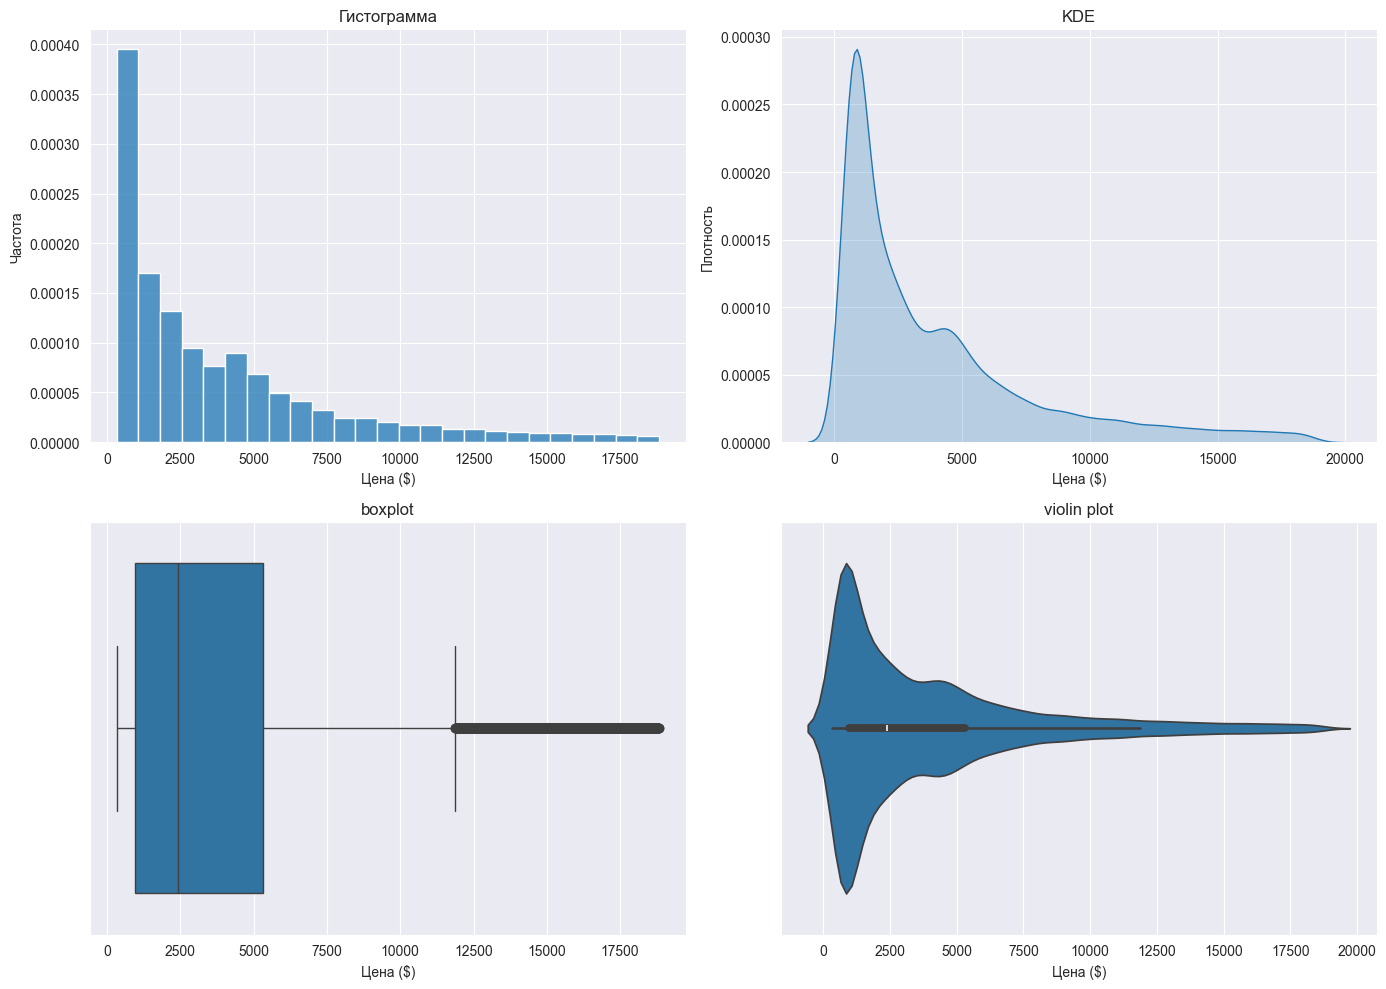

<Figure size 640x480 with 0 Axes>

In [17]:
# ЗАДАНИЕ:
#          1. Постройте 4 типа визуализации для столбца 'price'.
#          2. Подтвердите (или опровергните) выводы предыдущих пунктов о распределениях других столбцов.
#          3. Напишите итоговый вывод о распределении данных.

sns.set_style('darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Гистограмма
sns.histplot(diamonds['price'], bins=25, kde=False, ax=axes[0,0], stat='density')
axes[0,0].set_title('Гистограмма')
axes[0,0].set_xlabel('Цена ($)')
axes[0,0].set_ylabel('Частота')

# KDE-плотность
sns.kdeplot(diamonds['price'], ax=axes[0,1], fill=True)
axes[0,1].set_title('KDE')
axes[0,1].set_xlabel('Цена ($)')
axes[0,1].set_ylabel('Плотность')

# Boxplot
sns.boxplot(x=diamonds['price'], ax=axes[1,0])
axes[1,0].set_title('boxplot')
axes[1,0].set_xlabel('Цена ($)')

# Violinplot
sns.violinplot(x=diamonds['price'], ax=axes[1,1])
axes[1,1].set_title('violin plot')
axes[1,1].set_xlabel('Цена ($)')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

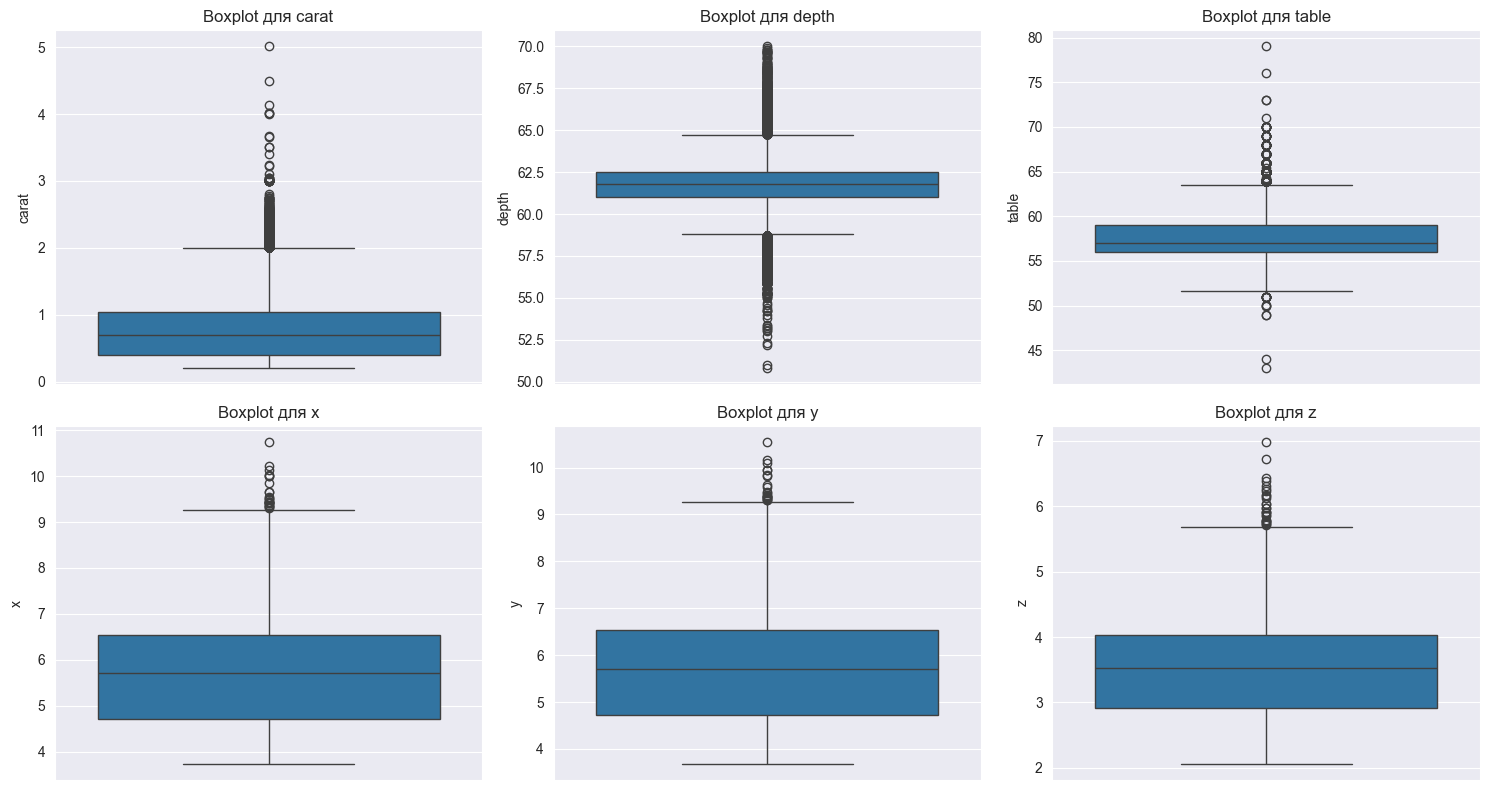

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
for i, col in enumerate(cols):
    row, col_idx = divmod(i, 3)
    sns.boxplot(y=diamonds[col], ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Boxplot для {col}')
    axes[row, col_idx].set_ylabel(col)
plt.tight_layout()
plt.show()

_Какой график лучше всего показывает асимметрию распределения? Какой график лучше выявляет выбросы? Почему для цен бриллиантов медиана — более репрезентативная мера, чем среднее?_


Я бы сказал, что легче всего определить ассиметрию и выбросы по boxplot, потому что он буквально отделяет квантили и точечно отображает выбросы, он ж для того и предназначен. Именно поэтому для всех остальных столбцов я использовал именно его. Возможно, он не такой наглядный, как все остальные, но если привыкнуть и научиться его читать быстро, мне он кажется наиболее удобным отображением данных: ничего лишнего, только главное.

На вопрос почему медиана более репрезентативная мера для цены я уже отвечал выше, повторюсь: среднее смещается за счёт наличия небольшого количества камней очень крупной цены. Их можно назвать выбросами. Из-за них среднее смещается, но "среднюю" цену всё ещё лучше всего отражает медиана.

### Итоговый вывод о распределениях данных:

**Категориальные признаки**
- Мода (`cut`): **Ideal** – наиболее частая огранка.
- Мода (`color`): **G** – самый распространённый цвет.
- Мода (`clarity`): **SI1** – преобладающий класс чистоты.

**Числовые признаки**
- `carat`: Среднее: 0.80, Медиана: 0.70, Skewness: 1.11, Kurtosis: 1.25 
    Распределение: Правосторонняя асимметрия, острый пик, тяжёлый правый хвост (редкие крупные камни) 
    Вывод о центральной мере: **медиана** 
- `depth`: Среднее: 61.75, Медиана: 61.80, Skewness: -0.16, Kurtosis: 2.78
    Распределение: Практически симметричное, очень острый пик, небольшие отклонения в обе стороны 
    Вывод о центральной мере: **медиана** (для однообразия, среднее тоже подойдет)
- `table`: Среднее: 57.44, Медиана: 57.00, Skewness: 0.70, Kurtosis: 1.30
    Распределение: правосторонняя асимметрия, острый пик, небольшой правый хвост 
    Вывод о центральной мере: **медиана**
- `x,y,z`: Среднее: 5.73, Медиана: 5.70, Skewness: 0.4, Kurtosis: -0.70
    Распределение: Слабая правосторонняя асимметрия, плосковершинное, лёгкие хвосты
    Вывод о центральной мере: **медиана** (для однообразия, среднее тоже подойдет)
- `price`: Среднее: 3932, Медиана: 2401, Skewness: 1.62, Kurtosis: 2.18
    Распределение: Правосторонняя асимметрия, острый пик, тяжёлый правый хвост (редкие дорогие камни)
    Вывод о центральной мере: **медиана**

- `carat` и `price` имеют ярко выраженную положительную асимметрию и высокий эксцесс. Это означает, что основная часть алмазов сосредоточена в области малых значений, но присутствует небольшое число крупных и очень дорогих экземпляров, которые образуют длинный правый хвост и сильно завышают среднее арифметическое. Для описания «типичного» камня по весу и цене необходимо использовать **медиану**.
- `depth` и `table` близки к симметричным распределениям с острыми пиками. Большинство камней имеют глубину 61–62% и ширину грани 56–59%, вариация невелика. Выбросы немногочисленны, но у table есть небольшая группа с аномально широким значением.
- Размеры `x`, `y`, `z` демонстрируют слабую положительную асимметрию и отрицательный эксцесс => равномерный разброс размеров и отсутствие сильных выбросов. Медиана и среднее практически совпадают, но для единообразия решено использовать **медиану**.

Построенные гистограммы, KDE-графики, boxplot и violinplot полностью подтвердили числовые выводы:
- Boxplot наглядно показал асимметрию и выбросы для `carat` и `price`.
- Для `depth` и `table` boxplot подтвердил симметричность и компактность.
- Violinplot для `price` дополнительно продемонстрировал форму распределения с длинным хвостом.

Распределения ключевых признаков могут быть "скошены", поэтому выбор мер центра и разброса нужно проводить внимательно. 

### Двумерный анализ (2 pt)

После того, как вы подробно изучили распределение каждого из признаков, перейдем к изучению «влияния» признаков друг на друга. 

**Двумерный анализ** — анализ взаимосвязи призваков друг с другом.  
Самым простым подходом является анализ **распределения одного признака в зависимости от значения другого** (например распределение цены для разной огранки), однако вы уже должны быть способны это сделать (условная фильтрация в pandas + визуализация распределения), поэтому останавливаться на этом мы сейчас не будем. _Но обязательно примените этот анализ во второй части!_

***

В этом задании остановимся на анализе **корреляций** признаков. Важно помнить, что **корреляция $\neq$ причинно-следственная связь**! Корреляция измеряет силу и направление связи между двумя числовыми признаками.

**Будем рассматривать два типа корреляции** (подробнее про [корреляцию](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D1%8F) в интренетах или на матстате):

| Тип корреляции | Что это такое | Когда использовать |
| -------------- | -------------- | ------------------ |
| **Пирсона** | 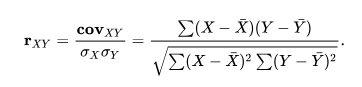 | Для линейных связей в нормально распределенных данных |
| **Спирмена** | Корреляция рангов | Для монотонных (не обязательно линейных) связей, устойчива к выбросам |

Документация: [.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html),
[.spearmanr()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).

Корреляцию можно интерпретировать по-разному (разные градации/шкалы), но в целом логика такая: чем больше, тем сильнее величины связаны, если знак отрицательный, то «рост» одной связан с «падением» другой.

In [19]:
# Нужно, наверное, убрать ещё и добавленные мной столбцы, которые я использовал на предобработке
diamonds = diamonds.drop(columns=['carat_est', 'carat_diff', 'xy_ratio'])

In [20]:
# Нетрудно заметить, что корреляция работает только для числовых признаков,
# поэтому выберем только числовые столбцы из данных

numeric_diamonds = diamonds.select_dtypes(include=[np.number])
# ЗАДАНИЕ:
#          1. Рассчитайте матрицу корреляций Пирсона для числовых признаков
pearson_corr = numeric_diamonds.corr(method='pearson')
print(pearson_corr)
#          2. Найдите пару признаков с самой сильной положительной корреляцией

# Из таблицы видно, что самая сильная корреляция - x и y
print()
print(pearson_corr['x'].sort_values(ascending=False).head(3))

#          3. Рассчитайте корреляцию Спирмена для этой же пары признаков
spearman_xy = numeric_diamonds[['x', 'y']].corr(method='spearman').iloc[0,1]
print(f"\nКорреляция Спирмена между x и y: {spearman_xy:.3f}")
#          4. Сравните значения Пирсона и Спирмена — отличаются ли они, почему?

          carat     depth     table     price         x         y         z
carat  1.000000  0.026657  0.181095  0.921718  0.978025  0.977302  0.977185
depth  0.026657  1.000000 -0.303912 -0.011205 -0.026272 -0.028962  0.094974
table  0.181095 -0.303912  1.000000  0.126124  0.195479  0.189480  0.155061
price  0.921718 -0.011205  0.126124  1.000000  0.887334  0.889015  0.882841
x      0.978025 -0.026272  0.195479  0.887334  1.000000  0.998899  0.991944
y      0.977302 -0.028962  0.189480  0.889015  0.998899  1.000000  0.991611
z      0.977185  0.094974  0.155061  0.882841  0.991944  0.991611  1.000000

x    1.000000
y    0.998899
z    0.991944
Name: x, dtype: float64

Корреляция Спирмена между x и y: 0.998


### Почему значения Пирсона и Спирмена не отличаются?
Корреляция Пирсона измеряет силу линейной зависимости. Корреляция Спирмена оценивает монотонную связь (не обязательно линейную).

В данном случае связь между размерами `x` и `y` у круглых алмазов должна быть строго линейной, исходя из физики дела (буквально по смыслу). Поэтому график зависимости x от y представляет собой практически прямую линию с небольшим разбросом.

Если бы связь была нелинейной, но монотонной, то Пирсон был бы ниже, а Спирмен – выше, так как он улавливает любую монотонную зависимость.

***
Оперировать числами довольно сложно, можно что-то пропустить. Как и написано в замечании в предыдущем разделе, проще «увидеть» гипотезы на картинке и уже числами их подтвердить. На помощь для двумерного анализа приходят новые типы графиков.

| Тип графика | Что показывает | Когда использовать | Ограничения | 
| ---------- | ------- | -------- | ------------- |
| **Heatmap** (тепловая карта) | Матрицу значений через цветовую кодировку | Быстрый обзор всех парных связей в числовых данных <br>Поиск сильных корреляций <br>Визуализация пропусков (`sns.heatmap(df.isna())`) |  Не показывает форму связи (линейная/нелинейная) <br>Трудно интерпретировать при >15 признаках |
| **Scatter plot** (точечная диаграмма) | Двумерное распределение точек | Анализ конкретной пары признаков <br>Проверка гипотезы о связи (напр., цена vs карат) <br>Визуализация категорий через цвет (`hue`) | Показывает только 2 признака за раз (+1 категориальный через `hue`) <br>Перекрытие точек при больших данных (`alpha` помогает) |
| **Pairplot** (матрица scatter plot) | Все попарные комбинации числовых признаков <br>Распределение на диагонали (гистограмма/KDE) | Быстрый обзор взаимосвязей в небольших датасетах (<10 признаков) <br>Поиск интересных пар для детального анализа | Квадратичная сложность: 10 признаков = 100 графиков! <br>Перегружен при большом количестве данных и долго считается |

Во всех этих графиках важна **настройка параметров** (иногда даже цветовая гпмма может влиять на интерпретируемость), поэтому внимательно посмотрите в документацию: [sns.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html),
[sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html),
[sns.pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

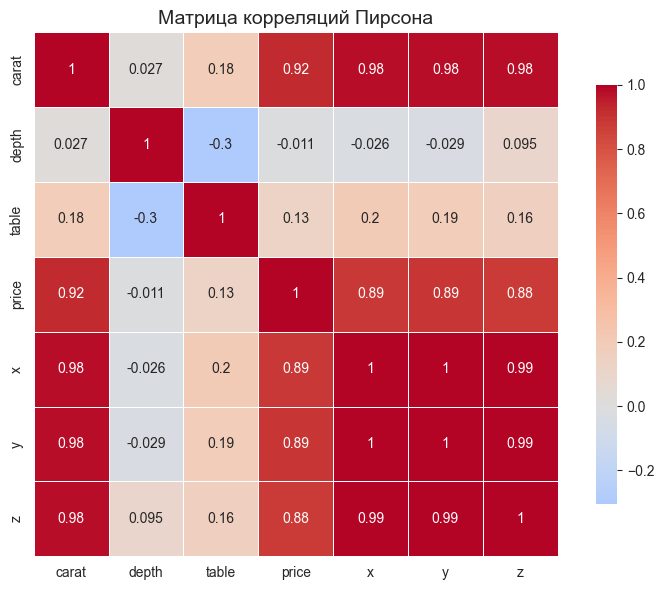

Пара с максимальной корреляцией: y и x, r = 0.999


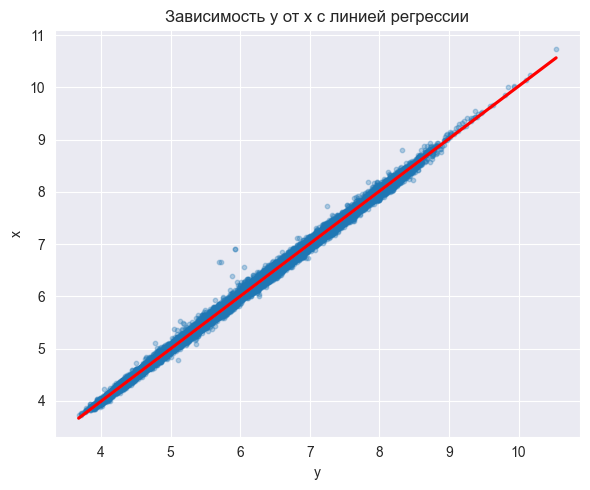

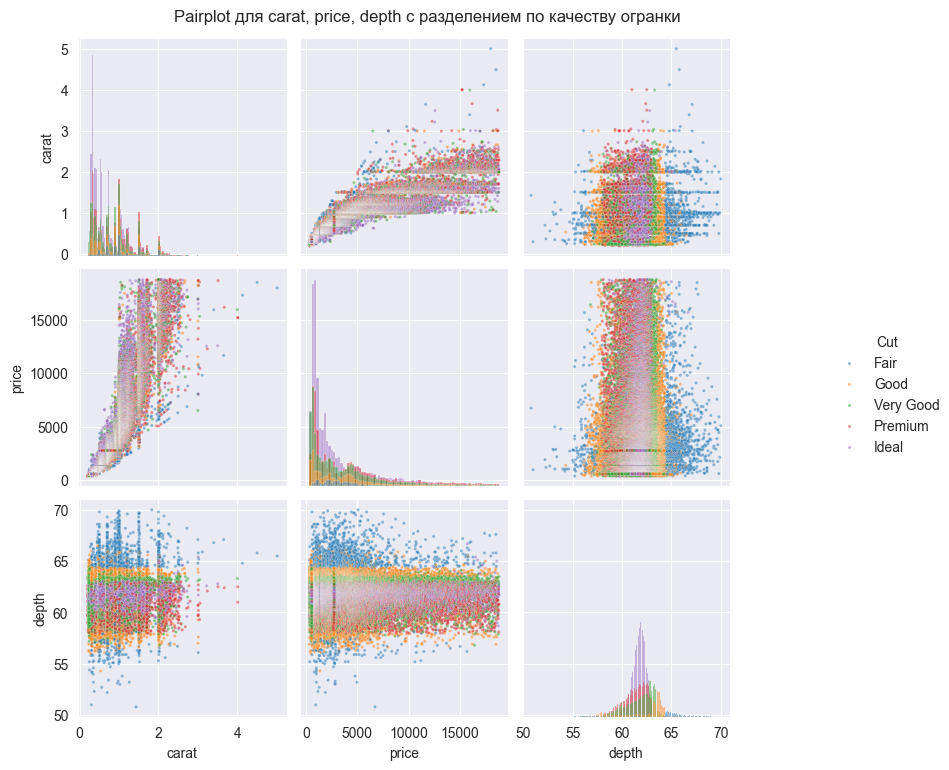

In [21]:
# ЗАДАНИЕ:
#          1. Постройте тепловую карту (heatmap) матрицы корреляций Пирсона
plt.figure(figsize=(8,6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций Пирсона', fontsize=14)
plt.tight_layout()
plt.show()
#          2. Постройте scatter plot для пары признаков с максимальной корреляцией
corr_pairs = pearson_corr.unstack().sort_values(kind="quicksort", ascending=False)
max_corr_pair = corr_pairs[(corr_pairs < 1)].idxmax()  # исключаем диагональ
print(f"Пара с максимальной корреляцией: {max_corr_pair[0]} и {max_corr_pair[1]}, r = {pearson_corr.loc[max_corr_pair[0], max_corr_pair[1]]:.3f}")

plt.figure(figsize=(6,5))
sns.regplot(data=diamonds, x=max_corr_pair[0], y=max_corr_pair[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title(f'Зависимость {max_corr_pair[0]} от {max_corr_pair[1]} с линией регрессии')
plt.tight_layout()
plt.show()
#             - Добавьте линию регрессии (sns.regplot)
#          3. Постройте pairplot для признаков ['carat', 'price', 'depth'] с цветовым разделением по 'cut'
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']

g = sns.pairplot(
    data=diamonds,
    vars=['carat', 'price', 'depth'],
    hue='cut',
    hue_order=cut_order,
    palette='tab10',          # Выбирал палитру, хотел наиболее контрастную, потому что иначе ничего не понятно
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 5}  # прозрачность и мелкие точки
)

# Перемещаем легенду за пределы основного блока
g._legend.set_bbox_to_anchor((1.1, 0.5))
g._legend.set_title('Cut')

# Подгоняем отступы, чтобы легенда не обрезалась
plt.subplots_adjust(right=0.85)
plt.suptitle('Pairplot для carat, price, depth с разделением по качеству огранки', y=1.02)
plt.show()

Как бы я не пытался подгонять pairplot, чтобы он выглядел более информативно, кажется, что всё равно получилась какая-то каша. 
Графики просто подтверждают действительность (??): Чем ближе форма камня к стандартам, тем лучше его качество огранки, тем выше его цена. 

### Дополнительное задание (1+ pt)

Проанализируйте влияние категориального признака `cut` (качество огранки) на распределение цены бриллиантов.

### Предварительно
Сравнивать влияние огранки только с ценой, абстрагируясь от веса, как по мне - мегастранно и нелогично. Очевидно, нужно привести цену к виду "цена за карат".

Помимо этого, важно также учитывать цвет и чистоту. Будем учитывать всё, проведём более детальный анализ.

_На самом деле, это не предварительно, а уже апостериорно. Я пытаюсь получить хоть какой-то осмысленный вывод кроме "огранка не влияет"_



Статистика цены за карат по весовым категориям и огранке

--- Весовая категория: мелкие ---
           count    mean  median    std     min     max      Q1      Q3
cut                                                                    
Fair          68  2493.1  2242.6  978.0  1374.1  6352.9  1989.3  2731.1
Good         934  1918.8  1841.7  429.8  1080.6  3912.5  1622.4  2180.2
Very Good   2972  2060.8  2025.3  441.7  1138.7  7886.7  1752.6  2300.0
Premium     3200  2307.1  2251.5  520.6  1078.1  4043.8  1911.8  2630.9
Ideal       7156  2365.7  2355.7  562.7  1109.1  6900.0  1962.5  2811.8
Разница median между ideal и premium: 104.18997668997645

--- Весовая категория: средние ---
           count    mean  median    std     min      max      Q1      Q3
cut                                                                     
Fair         339  2647.4  2560.0  845.2  1168.0   8564.7  2100.0  3122.7
Good        1166  2821.3  2776.9  786.3  1139.0   6756.0  2274.4  3282.1
Very Good   2713  2

C:\Users\olegs\AppData\Local\Temp\ipykernel_21656\745758281.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


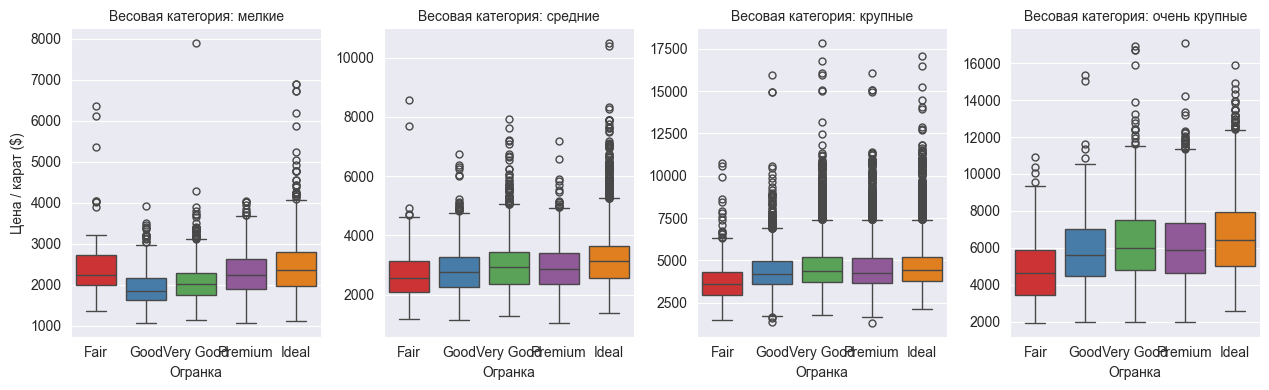

Статистика цены за карат для цвета G/H и чистоты VS1/VS2
           count    mean  median     std     min      max      Q1      Q3
cut                                                                      
Fair         156  4305.7  3910.0  1734.7  1760.0   9257.5  3055.7  5346.2
Good         559  4219.9  4018.3  2008.2  1403.2  10259.2  2478.8  5663.9
Very Good   1540  4214.1  3709.7  2109.8  1342.9  12460.7  2213.6  5860.4
Premium     2148  4444.0  3960.2  2190.2  1403.2  10656.3  2363.5  6048.1
Ideal       2874  4235.9  3393.0  2274.6  1468.0  10780.7  2250.0  6244.4


C:\Users\olegs\AppData\Local\Temp\ipykernel_21656\745758281.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_mid, x='cut', y='price_per_carat', order=cut_order, palette='Set1')


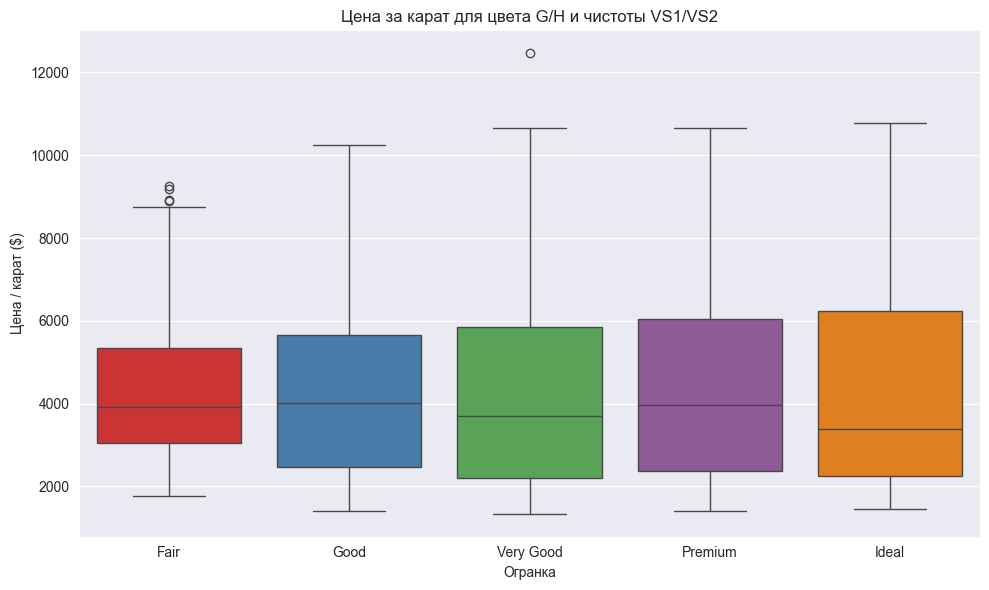

In [22]:
df = diamonds.copy()

# Весовые категории
df['carat_cat'] = pd.qcut(df['carat'], q=4, labels=['мелкие', 'средние', 'крупные', 'очень крупные'])
df['price_per_carat'] = df['price'] / df['carat']

cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

print("Статистика цены за карат по весовым категориям и огранке")

for cat in ['мелкие', 'средние', 'крупные', 'очень крупные']:
    print(f"\n--- Весовая категория: {cat} ---")
    subset_cat = df[df['carat_cat'] == cat]
    statistics = subset_cat.groupby('cut')['price_per_carat'].agg(['count', 'mean', 'median', 'std', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    statistics.columns = ['count', 'mean', 'median', 'std', 'min', 'max', 'Q1', 'Q3']
    statistics = statistics.reindex(cut_order)
    print(statistics.round(1))
    print(f'Разница median между ideal и premium: {subset_cat[subset_cat["cut"] == "Ideal"]["price_per_carat"].median() - subset_cat[subset_cat["cut"] == "Premium"]["price_per_carat"].median()}')

g = sns.catplot(
    data=df, x='cut', y='price_per_carat',
    col='carat_cat', kind='box',
    order=cut_order, palette='Set1',
    height=4, aspect=0.8, sharey=False
)
g.set_axis_labels('Огранка', 'Цена / карат ($)')
g.set_titles('Весовая категория: {col_name}')
plt.tight_layout()
plt.show()

print("Статистика цены за карат для цвета G/H и чистоты VS1/VS2")

subset_mid = df[df['color'].isin(['G','H']) & df['clarity'].isin(['VS1','VS2'])]
stats_mid = subset_mid.groupby('cut')['price_per_carat'].agg(['count', 'mean', 'median', 'std', 'min', 'max', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
stats_mid.columns = ['count', 'mean', 'median', 'std', 'min', 'max', 'Q1', 'Q3']
stats_mid = stats_mid.reindex(cut_order)
print(stats_mid.round(1))

plt.figure(figsize=(10,6))
sns.boxplot(data=subset_mid, x='cut', y='price_per_carat', order=cut_order, palette='Set1')
plt.title('Цена за карат для цвета G/H и чистоты VS1/VS2')
plt.xlabel('Огранка')
plt.ylabel('Цена / карат ($)')
plt.tight_layout()
plt.show()

### Выводы о влиянии огранки на цену
Чтобы исключить влияние веса, мы разделили все алмазы на четыре весовые категории по квартилям и сравнили медианную цену за карат для каждой огранки внутри одной весовой группы. Результаты **наконец-то** оказались очень показательными:

Во всех весовых категориях огранка Ideal даёт самую высокую медианную цену за карат, a Premium и Very Good конкурируют между собой, но всегда уступают Ideal. Что немаловажно, Good и Fair стабильно находятся внизу. (за исключением ситуации с мелкими камнями)

Это показывает, что при фиксированном весе более качественная огранка систематически повышает стоимость камня в пересчёте на карат. 
Гипотеза «огранка не влияет» опровергается.

Также рассмотрел самую распространённую комбинацию цвета и чистоты, чтобы увидеть, как огранка влияет на цену за карат в типичном сегменте рынка. Здесь, без контроля веса, картина иная: Ideal оказался самым дешёвым за карат. Однако, теперь мы понимаем, почему так: Ideal часто встречается среди мелких камней, у которых цена за карат объективно ниже. 

Мелкие интересные факты:
- Для крупных камней разрыв в цене между Ideal и Premium большой. Это может говорить о том, что ценность идеальной огранки для больших (дорогих) камней растёт.
- Для мелких камней средняя цена Fair почти та же, что и у Premium... Возможно, дело в маленькой выборке?


# Часть 2 (4 pt)

Теперь примените полученные навыки для анализа датасета **Palmer Penguins** — тоже стандартного датасета из `sns`. Этот датасет не такой большой, однако в нем можно найти интересные закономерности и больше узнать о пингвинчиках)

In [23]:
penguins = sns.load_dataset('penguins')
penguins.shape

(344, 7)

***
**ЗАДАНИЕ:** Проведите полный EDA датасета penguins.  
Для это проведите
* базовое **знакомство и чистку** данных (обосновывайте ваши действия),
* **одномерный анализ** всех признаков,
* **двумерный анализ** (не только корреляции, но и распределение при значениях других признаков),
* а также **сформулируйте 3 неочевидных вывода**, подкреплённых **статистикой/визуализацией**.

In [24]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Поискал, хочу себе зафиксировать для понимания: 
bill_length и bill_depth — это длина и глубина клюва пингвина 
flipper_length — длина ласта (крыла-плавника) пингвина 

In [25]:
diamonds.duplicated().sum()

0

In [26]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

### Итеративная преподготовка?
С одной стороны можно просто заполнить медианой или и вовсе снести эти строки. С другой стороны, хочется подойти к вопросу основательно.
Есть предположение, что масса влияет на размеры клюва / плавника, есть предположение, что пол может тоже как-то влиять на размеры или массу
Значит, можно вычислить наиболее вероятное и корректное заполнение пропуска, основываясь на этих зависимостях. 

Но чтобы так поступать, надо сначала понять, есть ли эти зависимости, а потом уже заполнить. Однако, как мы знаем, эти этапы идут в другой последовательности (мы сначала очищаем и подготавливаем данные, а уже потом отслеживаем зависимости и делаем выводы). Тогда как быть?

Кажется, что очистка и подготовка - итеративный процесс, и где-то мы ещё должны производить "вторую преподготовку данных" или даже третью и т.д.

Если мы можем провести предварительный мини-анализ, чтобы наиболее корректно заполнить пропуски и не потерять данные (а также связи в данных), мы поступим именно так. 

Для начала, посмотрим, что по пропускам в других столбцах в тех строках, в которых есть пропуски. Возможно, там и остальные пропущены, и наш подход не подойдёт


In [27]:
missing_rows = penguins[penguins.isnull().any(axis=1)]
print(missing_rows)

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
8    Adelie  Torgersen            34.1           18.1              193.0   
9    Adelie  Torgersen            42.0           20.2              190.0   
10   Adelie  Torgersen            37.8           17.1              186.0   
11   Adelie  Torgersen            37.8           17.3              180.0   
47   Adelie      Dream            37.5           18.9              179.0   
246  Gentoo     Biscoe            44.5           14.3              216.0   
286  Gentoo     Biscoe            46.2           14.4              214.0   
324  Gentoo     Biscoe            47.3           13.8              216.0   
336  Gentoo     Biscoe            44.5           15.7              217.0   
339  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g  sex  
3            NaN  NaN  
8         3475.0  NaN  
9         4250.

Возможно, для сравнения популяций нам были бы нужны те два пингвина, о которых кроме принадлежности ничего не известно. Тем не менее, восстанавливать остальные значения там не из чего, поэтому просто удалим строки, где все значения - пропуски

In [28]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_clean = penguins.dropna(subset=numeric_cols, how='all').reset_index(drop=True)
missing_rows = penguins_clean[penguins_clean.isnull().any(axis=1)]
print(missing_rows)

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
7    Adelie  Torgersen            34.1           18.1              193.0   
8    Adelie  Torgersen            42.0           20.2              190.0   
9    Adelie  Torgersen            37.8           17.1              186.0   
10   Adelie  Torgersen            37.8           17.3              180.0   
46   Adelie      Dream            37.5           18.9              179.0   
245  Gentoo     Biscoe            44.5           14.3              216.0   
285  Gentoo     Biscoe            46.2           14.4              214.0   
323  Gentoo     Biscoe            47.3           13.8              216.0   
335  Gentoo     Biscoe            44.5           15.7              217.0   

     body_mass_g  sex  
7         3475.0  NaN  
8         4250.0  NaN  
9         3300.0  NaN  
10        3700.0  NaN  
46        2975.0  NaN  
245       4100.0  NaN  
285       4650.0  NaN  
323       4725.0  NaN  
335       4875.0  NaN  

Теперь всё же вернёмся к "преанализу". Думаю, у разных видов в целом размеры отличаются, так что сравнивать всех пингвинов вместе было бы странно. Побьём их по видам, чтобы было наглядно.

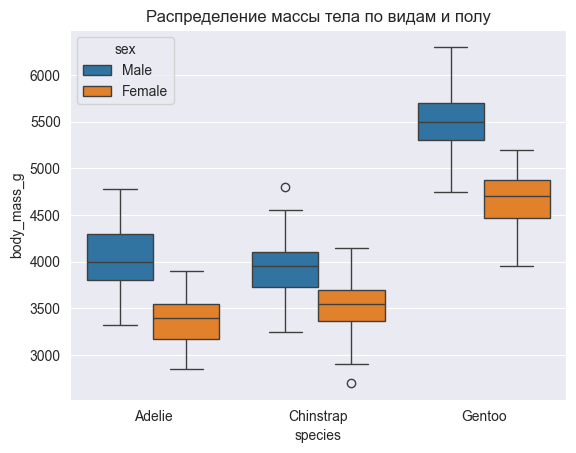

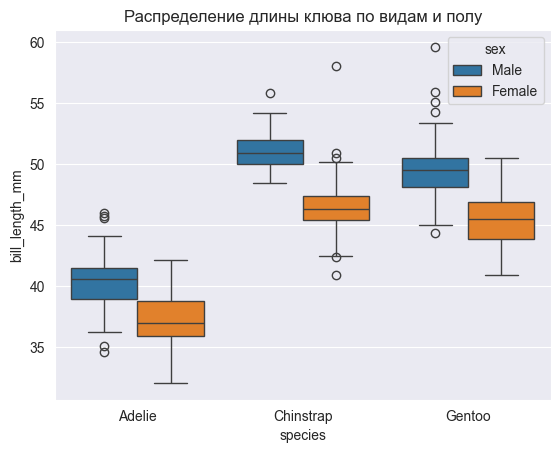

In [29]:
sns.boxplot(data=penguins_clean.dropna(subset=['sex']), x='species', y='body_mass_g', hue='sex')
plt.title('Распределение массы тела по видам и полу')
plt.show()

sns.boxplot(data=penguins_clean.dropna(subset=['sex']), x='species', y='bill_length_mm', hue='sex')
plt.title('Распределение длины клюва по видам и полу')
plt.show()

**Предположение оказалось верным!** обожаю boxplot`ы

Значит, самцы в среднем больше самок по всем параметрам для каждого из видов. Руководствуясь этим, заполним пропуски по полу грамотно!

In [30]:
def fill_sex(row):
    if pd.notna(row['sex']):
        return row['sex']
    # Если масса известна, используем её
    if pd.notna(row['body_mass_g']):
        # Вычисляем медиану массы для данного вида (по всем данным)
        median_mass = penguins_clean[penguins_clean['species'] == row['species']]['body_mass_g'].median()
        if row['body_mass_g'] > median_mass:
            return 'Male'
        else:
            return 'Female'
    # Если масса неизвестна, но известна длина клюва
    if pd.notna(row['bill_length_mm']):
        median_bill = penguins_clean[penguins_clean['species'] == row['species']]['bill_length_mm'].median()
        if row['bill_length_mm'] > median_bill:
            return 'Male'
        else:
            return 'Female'
    # Если ничего не известно, оставляем NaN
    return row['sex']

# Применяем функцию
penguins_clean['sex'] = penguins_clean.apply(fill_sex, axis=1)

# Теперь заполняем числовые пропуски медианами по группам (вид + пол)
for col in ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']:
    penguins_clean[col] = penguins_clean.groupby(['species', 'sex'])[col].transform(lambda x: x.fillna(x.median()))
    
#Проверяем, что всё заполнили
missing_rows = penguins_clean[penguins_clean.isnull().any(axis=1)]
print(missing_rows)

Empty DataFrame
Columns: [species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex]
Index: []


Получили empty DataFrame, значит, всё заполнено верно!! 

Давайте взглянем, есть ли аномалии в данных. 
Будем использовать IQR и z-score

In [31]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] < lower_bound) | (df[col] > upper_bound)]

def detect_outliers_zscore(df, col, threshold=3):
    # Удаляем NaN для вычисления z-score, но потом возвращаем полный df с индексами
    col_clean = df[col].dropna()
    z = np.abs(stats.zscore(col_clean))
    outlier_indices = col_clean.index[z > threshold]
    return df.loc[outlier_indices]

# Собираем все строки, которые являются выбросами хотя бы по одному признаку
outlier_rows = pd.DataFrame()

for col in numeric_cols:
    outliers_iqr = detect_outliers_iqr(penguins_clean, col)
    outliers_z = detect_outliers_zscore(penguins_clean, col)

    if not outliers_iqr.empty:
        print(f"\nВыбросы по IQR в '{col}':")
        print(outliers_iqr[['species', 'sex', 'island', col]])
        outlier_rows = pd.concat([outlier_rows, outliers_iqr])

    if not outliers_z.empty:
        print(f"\nВыбросы по Z-score в '{col}':")
        print(outliers_z[['species', 'sex', 'island', col]])
        outlier_rows = pd.concat([outlier_rows, outliers_z])

# Убираем дубликаты
outlier_rows = outlier_rows.drop_duplicates()

if not outlier_rows.empty:
    print("\nВсе уникальные строки, содержащие выбросы:")
    print(outlier_rows[['species', 'sex', 'island'] + numeric_cols])
else:
    print("\nВыбросов не обнаружено ни по одному признаку.")


Выбросов не обнаружено ни по одному признаку.


Даже жалко(
Ну, будем считать, что выбросов нет. Данные подготовили, переходим к одномерному анализу признаков (распределений)


Статистика bill_length_mm:
min: 32.1
max: 59.6
mean:43.9219
var: 29.8071
std: 5.4596
Квантили:
25%: 39.2250
50% (медиана): 44.4500
75%: 48.5000
Коэффициент асимметрии (skewness): 0.0531
Эксцесс (kurtosis): -0.8760


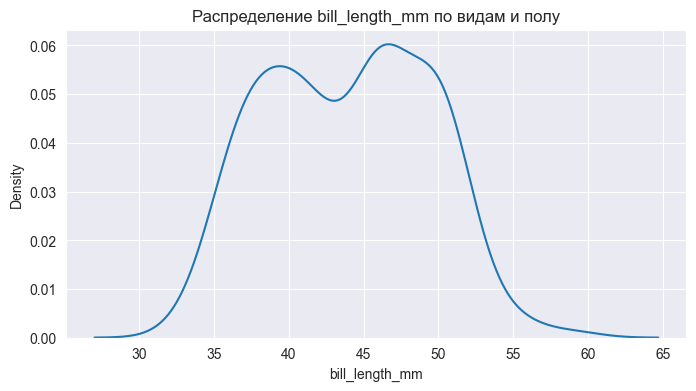


Статистика bill_depth_mm:
min: 13.1
max: 21.5
mean:17.1512
var: 3.8998
std: 1.9748
Квантили:
25%: 15.6000
50% (медиана): 17.3000
75%: 18.7000
Коэффициент асимметрии (skewness): -0.1435
Эксцесс (kurtosis): -0.9069


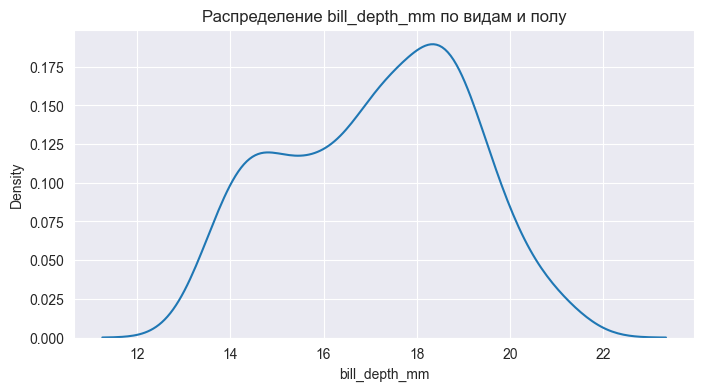


Статистика flipper_length_mm:
min: 172.0
max: 231.0
mean:200.9152
var: 197.7318
std: 14.0617
Квантили:
25%: 190.0000
50% (медиана): 197.0000
75%: 213.0000
Коэффициент асимметрии (skewness): 0.3457
Эксцесс (kurtosis): -0.9843


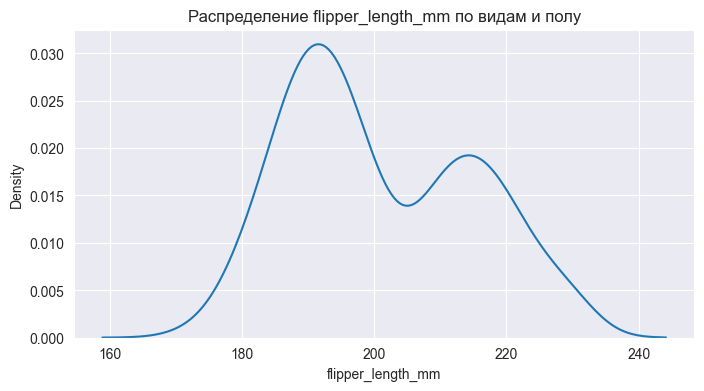


Статистика body_mass_g:
min: 2700.0
max: 6300.0
mean:4201.7544
var: 643131.0773
std: 801.9545
Квантили:
25%: 3550.0000
50% (медиана): 4050.0000
75%: 4750.0000
Коэффициент асимметрии (skewness): 0.4703
Эксцесс (kurtosis): -0.7192


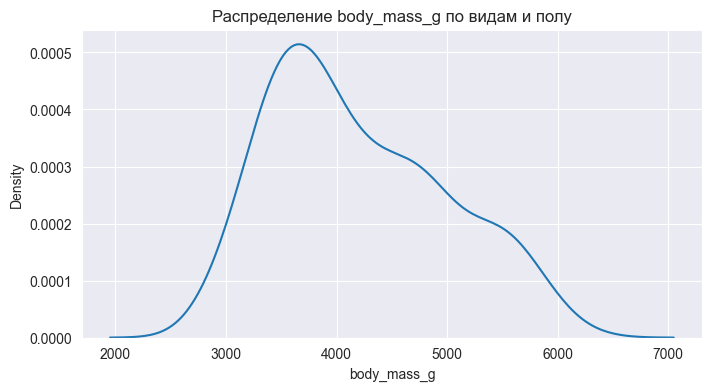

In [32]:
for col in numeric_cols:
    quantils = penguins_clean[col].quantile([0.25, 0.5, 0.75])
    print(f"\nСтатистика {col}:")
    print("min:", penguins_clean[col].min())
    print("max:", penguins_clean[col].max())
    print(f"mean:{penguins_clean[col].mean():.4f}")
    print(f"var: {penguins_clean[col].var():.4f}")
    print(f"std: {penguins_clean[col].std():.4f}")
    print(f"Квантили:")
    print(f"25%: {quantils.iloc[0]:.4f}")
    print(f"50% (медиана): {quantils.iloc[1]:.4f}")
    print(f"75%: {quantils.iloc[2]:.4f}")
    print(f"Коэффициент асимметрии (skewness): {penguins_clean[col].skew():.4f}")
    print(f"Эксцесс (kurtosis): {penguins_clean[col].kurtosis():.4f}")
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=penguins_clean, x=col)
    plt.title(f'Распределение {col} по видам и полу')
    plt.show()



Кажется, что это неинформативно. Мы не можем сделать никаких качественных выводов, основываясь на распределении одного признака. Единственный вывод, который мне кажется важным и ключевым, который можно сделать из одномерного анализа:

Плосковершинность: все признаки имеют отрицательный эксцесс. Мы знаем, что указывает на то, что распределения более пологие по сравнению с нормальным.
 
**Если бы мы не знали, что данные состоят из нескольких подгрупп (разные виды, разный пол), то мы бы могли на этом этапе сделать такое предположение -  у нас в данных несколько подгрупп со сдвинутым средним**

Перейдём к двумерному анализу, посмотрим распределения числовых характеристик по виду и полу, используя мои любимые boxplot

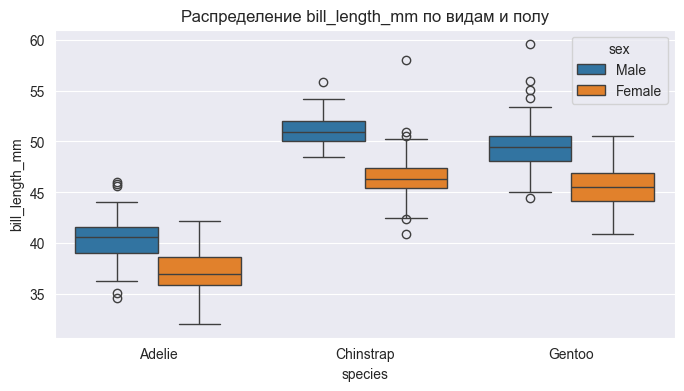

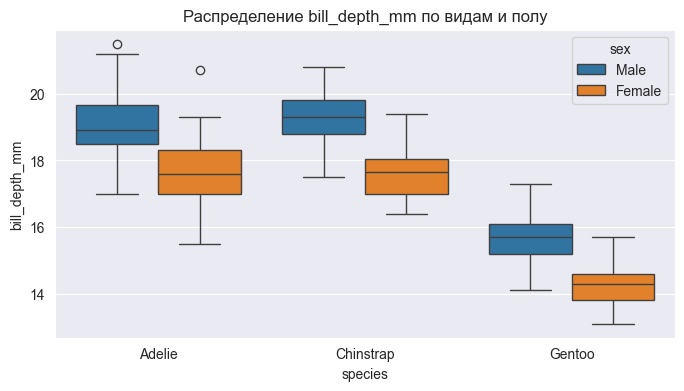

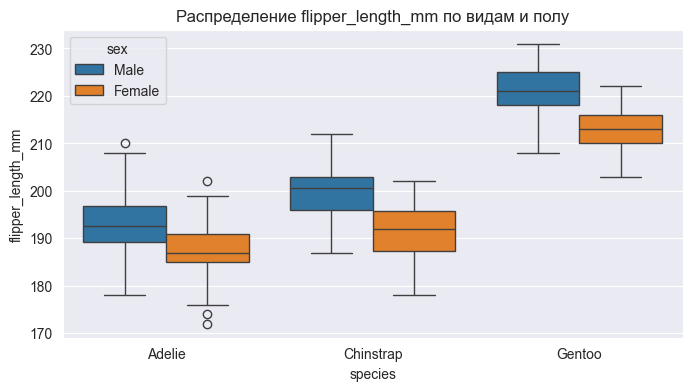

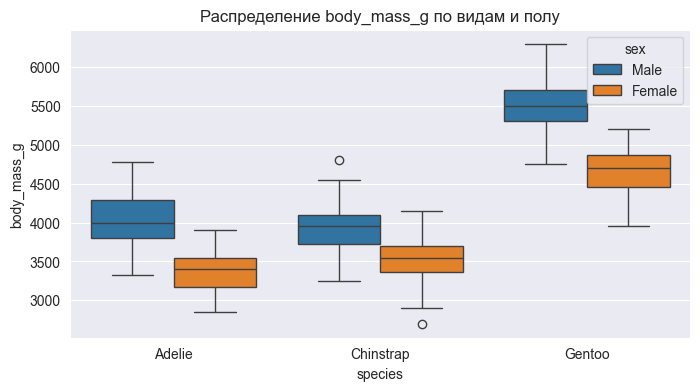

In [33]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=penguins_clean, x='species', y=col, hue='sex')
    plt.title(f'Распределение {col} по видам и полу')
    plt.show()

Увидел, что пингвины вида Adelie живут на всех трёх островах. Может, их характеристики зависят от острова?

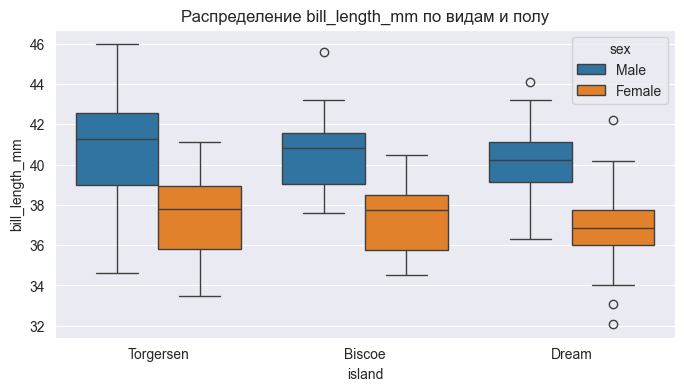

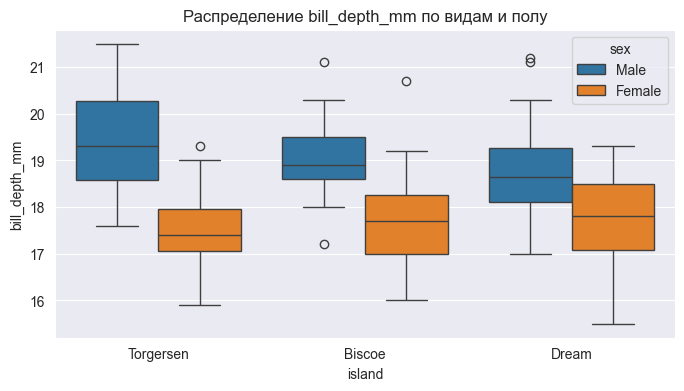

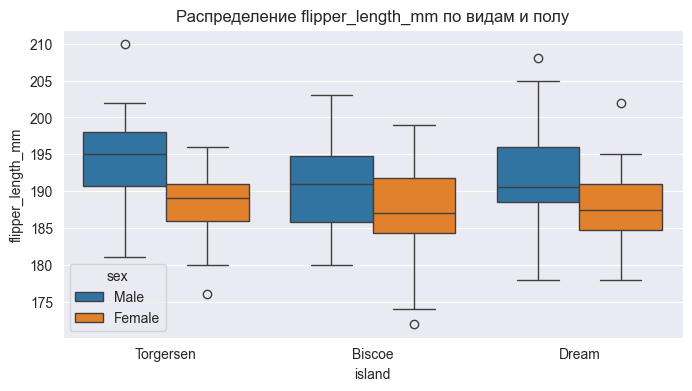

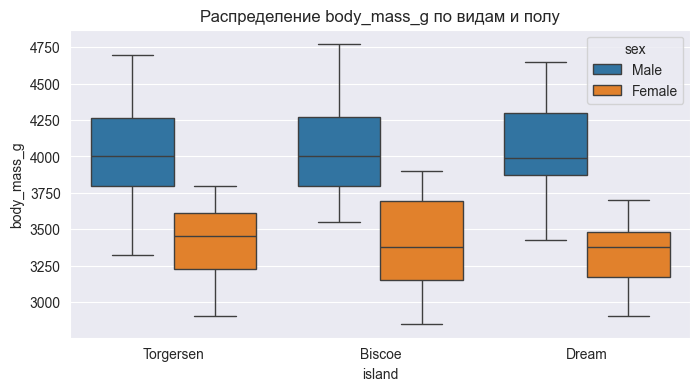

In [34]:
adelie = penguins_clean[penguins_clean['species'] == 'Adelie']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=adelie, x='island', y=col, hue='sex')
    plt.title(f'Распределение {col} по видам и полу')
    plt.show()

### Промежуточные выводы из двумерного анализа:
- Размеры самцов в среднем больше самок по всем параметрам для каждого из видов (это мы уже выяснили на предварительном анализе
- Пингвинчики вида Gentoo гораздо больше весят, имеют больший размер плавника, но менее глубокий клюв 
- Пингвинчики вида Adelie имеют короткий (относительно других видов) клюв.
- Место обитания не влияет на размеры пингвина и его массу (для вида adelie). Boxplot`ы характеристик на разных островах очень похожи

Сделаем ещё один минианализ перед корреляционным, который будет очень важен в дальнейшем _(пишу это постфактум, меняю порядок ячеек, чтобы повествование было более логичным, и я не обращался к выводам из последующих ячеек)_

Всегда хочется как-то попреобразовывать данные, подобавлять новых столбцов, чтобы поискать более интересные факты/зависимости. В этом датасете, как по мне, напрашивается такой параметр как "форма клюва" особи - к примеру, отношению длины клюва к его глубине. Сделаем вывод о том, как отличается форма клюва в зависимости от вида и пола

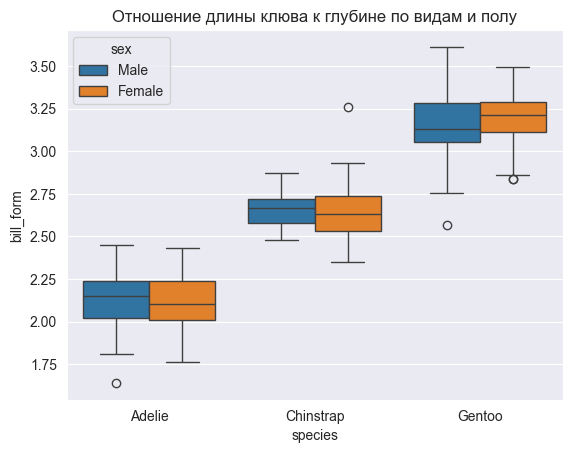

In [35]:
penguins_clean['bill_form'] = penguins_clean['bill_length_mm'] / penguins_clean['bill_depth_mm']

sns.boxplot(data=penguins_clean, x='species', y='bill_form', hue='sex')
plt.title('Отношение длины клюва к глубине по видам и полу')
plt.show()

### Промежуточный вывод
У всех видов отношение длины клюва к глубине отличается! У Gento клюв более длинный/узкий, а у Adelie более короткий/широкий. Ну прикольно, гипотеза подтвердилась.

Теперь перейдём к корреляционному анализу:

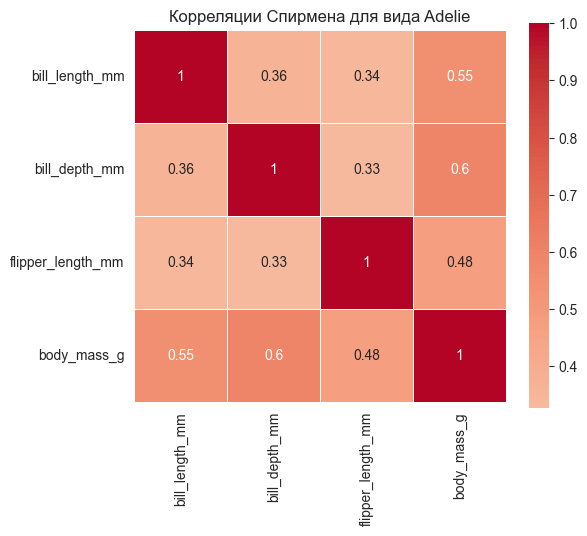

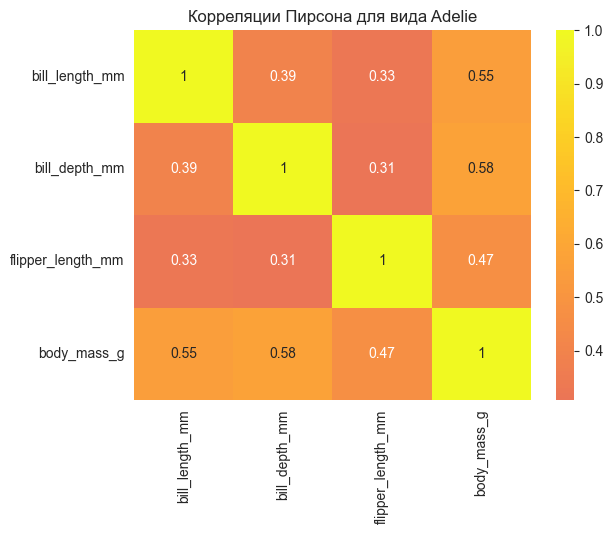

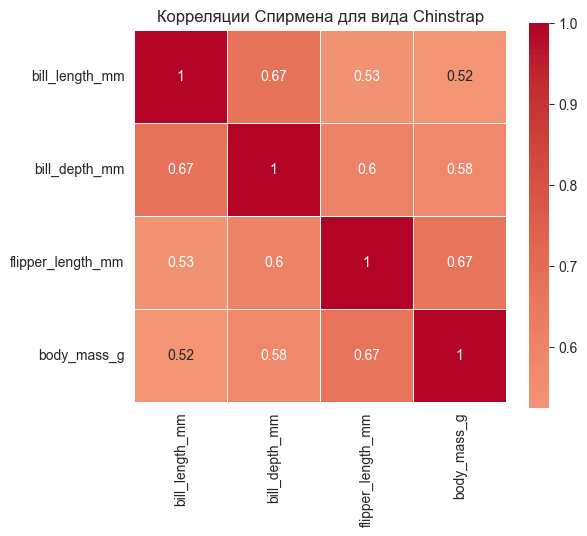

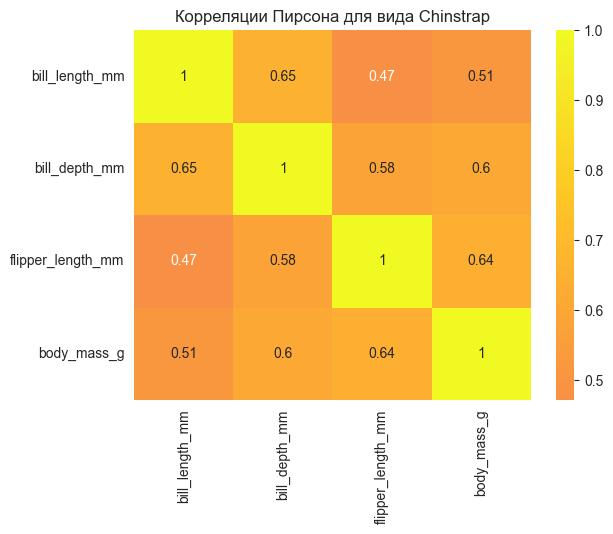

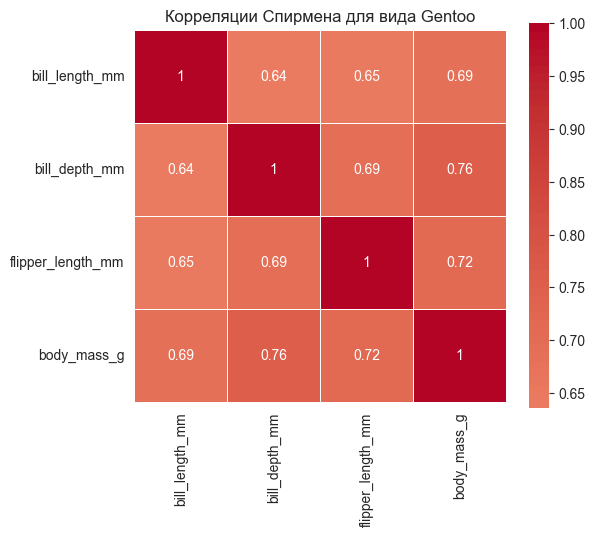

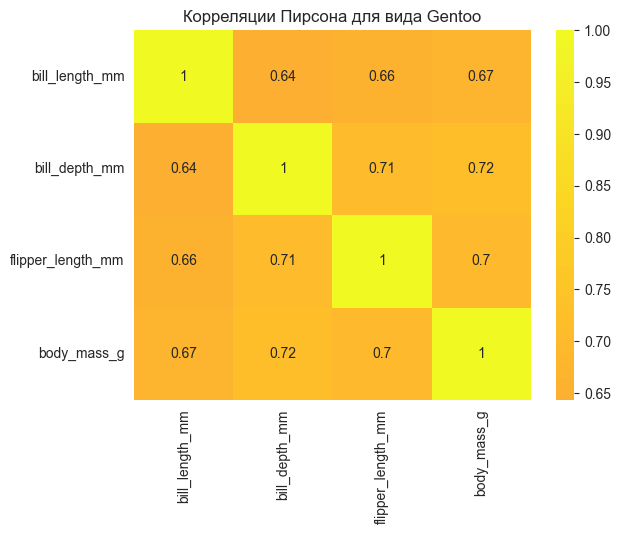

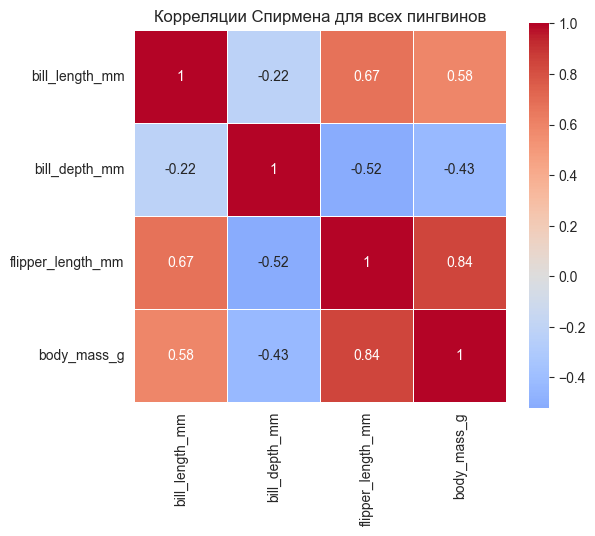

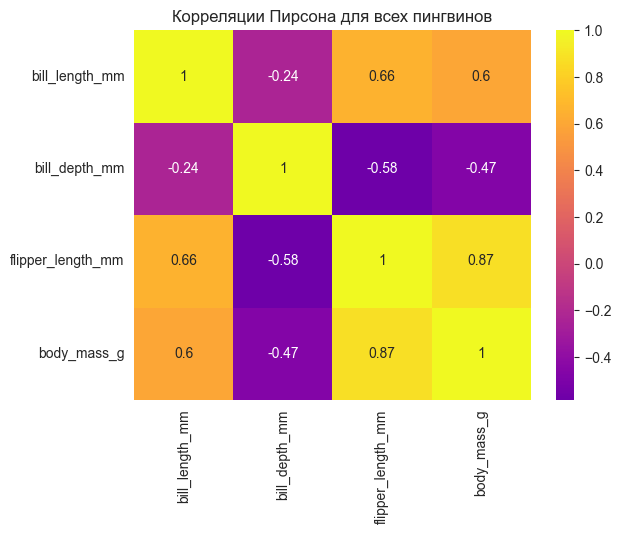

In [36]:
for species in penguins_clean['species'].unique():
    subset = penguins_clean[penguins_clean['species'] == species]
    plt.figure(figsize=(6,5))
    sns.heatmap(subset[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title(f'Корреляции Спирмена для вида {species}')
    plt.show()
    sns.heatmap(subset[numeric_cols].corr(method='pearson'), annot=True, cmap='plasma', center=0,)
    plt.title(f'Корреляции Пирсона для вида {species}')
    plt.show()
    
# Сделаем отдельный heatmap для всех пингвинов

plt.figure(figsize=(6,5))
sns.heatmap(penguins_clean[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title(f'Корреляции Спирмена для всех пингвинов')
plt.show()
sns.heatmap(penguins_clean[numeric_cols].corr(method='pearson'), annot=True, cmap='plasma', center=0,)
plt.title(f'Корреляции Пирсона для всех пингвинов')
plt.show()

### Промежуточный вывод

Тут я очень удивился. Самое интересное не в матрицах каждого вида отдельно, там всё довольно прозаично: если что-то больше, скорее всего, больше и всё остальное. Поэтому мне захотелось узнать, что будет, если я построю матрицу корреляций для всех пингвинов. Получилась совершенно неочевидная для меня картина: Если рассматривать всех пингвинов вместе, то глубина клюва будет иметь отрицательную корреляцию со всеми остальными параметрами, а если внутри вида, то положительную! Помимо этого, корреляция между массой и длиной плавника стала сильнее, чем у какого либо вида в отдельности!

Честно говоря, я сначала был в растерянности, подумал, что что-то сделал не так. Позже, я всё-таки нашёл логическое обоснование этому:

**Дело в том, что пингвины разных видов сильно отличаются по размеру!** Когда считаем корреляцию по всем данным вместе, основным источником изменчивости становятся межвидовые различия. Внутри каждого вида разброс относительно невелик, но между видами он огромен. Попробую объяснить подробнее:

У Gentoo, при общих крупных размерах, клюв не только длинный, но и имеет меньшую глубину (что мы частично подтвердили в минианализе формы клюва). У Adelie, наоборот, клюв короче, но глубже.
Таким образом, при переходе от мелких видов к крупным, длина клюва, масса и длина плавника растут, а глубина клюва падает!

**Это и создаёт отрицательную корреляцию глубины клюва с остальными признаками!**

_Очень клёво было наткнуться на такое, не знаю, является ли это ключевой особенностью датасета, но мне мегапонравилось)_

Было также замечено, что корреляция между массой и длиной плавника стала сильнее. Думаю, лучшим вариантом понять почему так получается, будет иллюстрация в следующей ячейке.

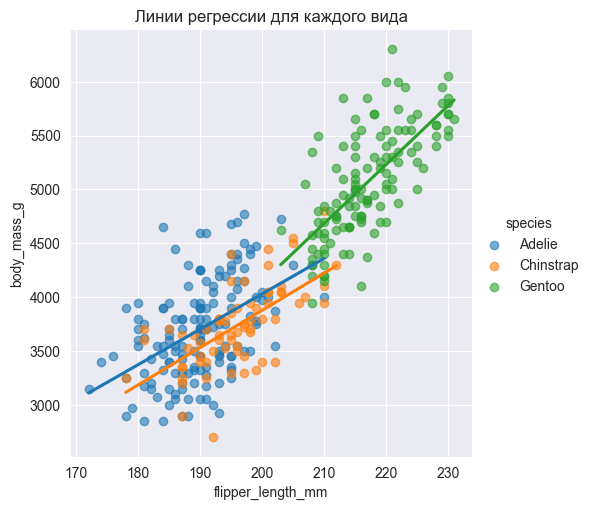

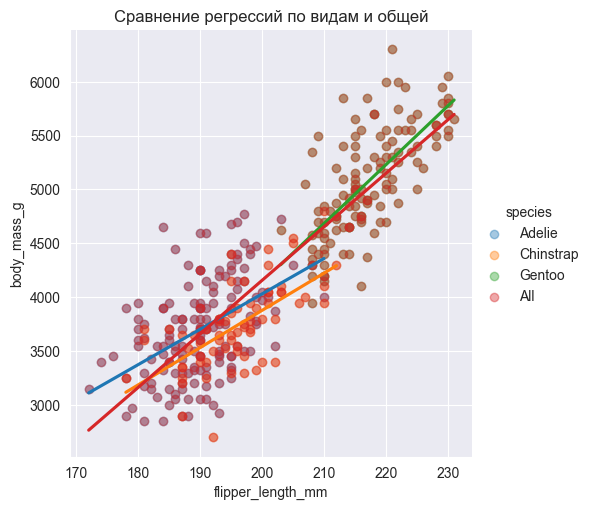

In [37]:
# График с отдельными линиями для каждого вида
sns.lmplot(data=penguins_clean, x='flipper_length_mm', y='body_mass_g',
           hue='species', ci=None, scatter_kws={'alpha':0.6})
plt.title('Линии регрессии для каждого вида')
plt.show()

# Создаём копию с новой меткой для всех данных
penguins_all = penguins_clean.copy()
penguins_all['species'] = 'All'

# Объединяем
combined = pd.concat([penguins_clean, penguins_all])

sns.lmplot(data=combined, x='flipper_length_mm', y='body_mass_g',
           hue='species', ci=None, scatter_kws={'alpha':0.4})
plt.title('Сравнение регрессий по видам и общей')
plt.show()

### Ошибка
Так был рождён ещё один вывод, относящийся скорее к методу, нежели к данным. Я думал, что если корреляция выше, то и наклон линии регрессии должен быть выше... На самом деле если мы посмотрим на график, то увидим, что линия регрессии Gentoo более крутая, чем All, несмотря на то, что корреляция у All выше. Корреляция и наклон линии регрессии тесно связаны, но совсем не одно и то же.

Вот почему так:
Наклон линии регрессии = $r \cdot \frac{\sigma_y}{\sigma_x}$, где $r$ - коэффициент корреляции, $\sigma_x$ - std для $x$, $\sigma_y$ - std для $y$.
У Gentoo: $r$ = 0.7, $\sigma_x$ относительно маленький $\sigma_y$ - относительно большой
У всех пингвинов вместе: $r$ = 0.87, $\sigma_x$ - большое, $\sigma_y$ - тоже большое, но $\sigma_x$ выросло ещё сильнее

В итоге наклон получился более пологим, хотя корреляция выше. Получили довольно глупый, но полезный минивывод (формулы то изначально были разные, корреляция внутри наклона, зависит не только от него, они не про одно и то же)

Видимо, наглядно объяснить это не получится, попробуем объяснить словами:

Корреляция выросла, потому что появились систематические различия между видами. Общая изменчивость увеличилась, а точки по-прежнему группируются вдоль одной линии. У Gentoo же изменчивость только внутривидовая, поэтому корреляция отражает именно внутривидовую связь, которая слабее.

## Итоговый вывод!!
Здесь я просто сделаю некое саммари, вкратце тезисно описав всё то, что получил в промежуточных выводах:

### Одномерный анализ:
- все признаки имеют отрицательный эксцесс (от -0.7 до -0.98). Это указывает на то, что распределения более плосковершинны по сравнению с нормальным. Такая форма часто возникает, когда данные состоят из нескольких подгрупп.
- Коэффициенты асимметрии близки к нулю (от -0.14 до 0.47), что говорит о симметричности распределений и позволяет использовать среднее как меру центральной тенденции, хотя медиана предпочтительнее из-за возможного влияния подгрупп.

### Двумерный анализ:
Boxplot-анализ показал:
- У всех трёх видов самцы в среднем крупнее самок по всем четырём признакам.
- Gentoo – самый крупный вид: они имеют наибольшую массу, самые длинные плавники и самый длинный клюв, но при этом наименьшую глубину клюва.
- Adelie обладают самым коротким клювом среди видов.
- Chinstrap занимают промежуточное положение по большинству признаков.

Дополнительно проверил, влияет ли остров обитания на размеры пингвинов вида Adelie (единственного вида, встречающегося на всех трёх островах). Boxplot’ы не выявили значимых различий – можно сделать вывод, что местоположение не влияет на форму клюва и вес Adelie.

### Анализ формы клюва
Ввёл новый признак – отношение длины клюва к его глубине, характеризующий форму клюва.
Оказалось, что у всех трёх видов это отношение существенно различается:
- Gentoo имеют самое высокое отношение (клюв длинный и узкий).
- Adelie – самое низкое (клюв короткий и широкий).
- Chinstrap, как всегда, занимают промежуточное положение.
Позже этот признак помог для понимания эффекта отрицательной корреляции depth с остальными признаками

### Корреляционный анализ
Рассчитал корреляции Пирсона и Спирмена отдельно для каждого вида и для всех данных вместе.

Внутривидовые корреляции оказались умеренными, максимум около 0.7 для пары «длина плавника – масса» у Gentoo. В целом, внутри вида наблюдается ожидаемая картина: более крупные особи имеют бо́льшие значения по всем признакам, но связь не очень тесная.

Межвидовые корреляции (по всем данным вместе) дали неожиданные результаты:
- Корреляция между длиной плавника и массой тела резко возросла до 0.87 (против 0.7 у Gentoo).
- Глубина клюва стала отрицательно коррелировать со всеми остальными признаками (например, с длиной клюва около –0.43).

Почему так произошло?
Причина – в межвидовой изменчивости. Пингвины разных видов систематически различаются по размерам:
- Gentoo – крупные, с длинными плавниками, большой массой, но мелким клювом.
- Adelie – мельче, с более короткими плавниками, меньшей массой, но глубоким клювом.
- Chinstrap – средние.

При объединении видов основной вклад в разброс вносят именно межвидовые различия, а не внутривидовые. Для глубины клюва направление изменчивости противоположно остальным признакам, поэтому корреляция становится отрицательной.

### Прочее
При интерпретации результатов столкнулся с проблемой: корреляция для всех данных выше, чем для Gentoo, но линия регрессии для Gentoo оказалась круче. Это объясняется формулой наклона. 


## Три неочевидных вывода
1) Форма клюва оказалась очень крутым и показательным признаком: значения практически не перекрываются между видами. Можно было бы использовать его для классификации (по этому признаку можно было бы заполнять пропуски в видах), что мне кажется очень крутым фактом.
2) Сравнивая корреляции, очень важно смотреть как и корреляции по категориям, так и корреляции во всём датасете. Оказывается, матрицы корреляции могут дать абсолютно разные результаты. Корреляции в датасете будут говорить о том, как соотносятся признаки между категориями.
3) Изначально я, честно говоря, не понимал, зачем нужны асимметрия и эксцесс. Казалось, что это просто абстрактные статистические характеристики, как делать по ним содержательные, полезные выводы, кроме как "похоже на нормальное", "несимметрично" - непонятно. Однако при анализе пингвинов мне пришла в голову интересная мысль: **отрицательный эксцесс может указывать на то, что данные состоят из нескольких групп со сдвинутыми средними**.


**УДОСТОВЕРЬТЕСЬ, ЧТО ВСЕ ВАШИ ВЫВОДЫ И КОД ОФОРМЛЕНЫ ТАК, ЧТОБЫ ЛЕГКО МОЖНО БЫЛО ПОНЯТЬ, К ЧЕМУ ОНИ ОТНОСЯТСЯ**  
**НЕ ЗАБУДЬТЕ ПЕРЕЗАПУСТИТЬ НОУТБУК ТАК, ЧТОБЫ ВСЕ ЯЧЕЙКИ БЫЛИ ЗАПУЩЕНЫ ПОДРЯД, НАЧИНАЯ С [1]**